In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(''))

import warnings
warnings.filterwarnings('ignore')

from modeling.data_preprocessing import *

DATA_DIR = os.path.join('..', 'data', 'fully combined')

datasets = load_datasets(DATA_DIR)
qb_raw = datasets['qb_raw']
rb_raw = datasets['rb_raw']
te_raw = datasets['te_raw']
wr_raw = datasets['wr_raw']


QB: 845 redova x 188 kolona | Sezone: 1979-2025
RB: 622 redova x 115 kolona | Sezone: 1988-2025
TE: 351 redova x 70 kolona | Sezone: 1990-2025
WR: 5502 redova x 102 kolona | Sezone: 2015-2025


In [2]:
qb, rb, te = prepare_qb_rb_te(qb_raw, rb_raw, te_raw)
wr = prepare_wr(wr_raw)

print_target_summary(qb, rb, te, wr)


Ciljne promenljive:
QB (Yds/G):       mean=223.72, median=231.05, min=0.00, max=371.20 | Sezone: 1979-2025
RB (Yds/G):       mean=63.07, median=65.16, min=-0.23, max=131.06 | Sezone: 1988-2025
TE (Yds/G):       mean=39.37, median=39.07, min=0.00, max=94.40 | Sezone: 1990-2025
WR (Yds/G raw):   mean=22.39, median=16.57, min=-16.00, max=116.94
WR (log1p Yds/G): mean=2.737, median=2.866, min=0.000, max=4.770


In [3]:
qb, rb, te = apply_award_encoding(qb, rb, te)
print_award_summary(qb, rb, te)


Award encoding — broj sezona po kategoriji:

Nagrada                  QB     RB     TE
--------------------------------------
award_PB                262    152     93
award_AP1                40     52     28
award_AP2                37     39     20
award_MVP_top5           92     28      0
award_OPoY_top5          89     46      4


In [4]:
analyze_nulls_by_position(qb, rb, te, wr)


  QB — kolone sa null vrednostima (156 od 194)
  Kolona                               Null#   Null%
  ----------------------------------------------------
  adv_rr_rec_broken_tackles_per_rec      781   99.6%
  adv_rr_rec_yac_per_rec                 748   95.4%
  adv_rr_rec_air_yds_per_rec             748   95.4%
  adv_rr_rec_adot                        736   93.9%
  adv_rr_rec_pass_rating                 736   93.9%
  adv_rr_rec_drop_pct                    736   93.9%
  rr_rec_long                            686   87.5%
  rr_rec_yds_per_rec                     686   87.5%
  rr_rec_success                         657   83.8%
  rr_rec_yds_per_tgt                     657   83.8%
  rr_catch_pct                           657   83.8%
  adv_rr_Rush_BrkTkl/A                   649   82.8%
  adv_pass_pass_on_target_pct            557   71.0%
  adv_pass_pass_rpo_rush_yds             556   70.9%
  adv_pass_pass_rpo_pass_yds             556   70.9%
  adv_pass_pass_rpo                      556   70

In [5]:
qb, rb, te = drop_metadata_columns_qb_rb_te(qb, rb, te)
wr = drop_unused_columns_wr(wr)
adv_cols_to_drop = [c for c in qb.columns if c.startswith('adv_')]
qb.drop(columns=adv_cols_to_drop, inplace=True)
qb, rb, te, wr = drop_extra_columns(qb, rb, te, wr)
qb, rb, te = drop_awards_raw(qb, rb, te)
qb = drop_qb_qbr(qb)
rb = drop_rb_receiving_cols(rb)
te = drop_te_rushing_cols(te)
wr = drop_wr_def_dev_cols(wr)

In [6]:
print_shape_and_columns(qb, rb, te, wr)

Pozicija  Kolona  Redova
-------------------------
QB          42     784
RB          24     622
TE          29     350
WR          48    5502

  QB — 42 kolona x 784 redova
    1. Player
    2. Season
    3. Age
    4. Team
    5. G
    6. GS
    7. Cmp
    8. Att
    9. Cmp%
   10. Yds
   11. TD
   12. Int
   13. 1D
   14. Succ%
   15. Y/A
   16. AY/A
   17. Y/C
   18. Rate
   19. Sk
   20. Yds_Lost
   21. NY/A
   22. ANY/A
   23. 4QC
   24. GWD
   25. AV
   26. adj_ANY/A+
   27. adj_AY/A+
   28. adj_Cmp%+
   29. adj_Int%+
   30. adj_NY/A+
   31. adj_Rate+
   32. adj_Sack%+
   33. adj_TD%+
   34. adj_Y/A+
   35. Team_Changed
   36. Prev_Season_Yds
   37. target
   38. award_PB
   39. award_AP1
   40. award_AP2
   41. award_MVP_top5
   42. award_OPoY_top5

  RB — 24 kolona x 622 redova
    1. Player
    2. Season
    3. Age
    4. Team
    5. G
    6. GS
    7. Rush_Att
    8. Rush_Yds
    9. Rush_TD
   10. Rush_1D
   11. Rush_Succ%
   12. Rush_Lng
   13. Rush_Y/A
   14. Rush_A/G
   1

In [7]:
analyze_nulls_by_position(qb, rb, te, wr)


  QB — kolone sa null vrednostima (11 od 42)
  Kolona                               Null#   Null%
  ----------------------------------------------------
  adj_ANY/A+                              18    2.3%
  adj_AY/A+                               18    2.3%
  adj_Cmp%+                               18    2.3%
  adj_Int%+                               18    2.3%
  adj_NY/A+                               18    2.3%
  adj_Rate+                               18    2.3%
  adj_Sack%+                              18    2.3%
  adj_TD%+                                18    2.3%
  adj_Y/A+                                18    2.3%
  Succ%                                    1    0.1%
  Y/C                                      1    0.1%

  RB — kolone sa null vrednostima (4 od 24)
  Kolona                               Null#   Null%
  ----------------------------------------------------
  Rush_Succ%                               3    0.5%
  Rush_Lng                                 3    0.5%
  Ru

In [8]:
POS_CONFIG = {
    'QB': dict(df=qb, player_col='Player', season_col='Season',
               static_feats=['Age', 'Team_Changed'],
               id_cols=['Player', 'Season', 'Team']),
    'RB': dict(df=rb, player_col='Player', season_col='Season',
               static_feats=['Age', 'Team_Changed'],
               id_cols=['Player', 'Season', 'Team']),
    'TE': dict(df=te, player_col='Player', season_col='Season',
               static_feats=['Age', 'Team_Changed'],
               id_cols=['Player', 'Season', 'Team']),
    'WR': dict(df=wr, player_col='receiver_player_name', season_col='season',
               static_feats=['age', 'team_changed'],
               id_cols=['receiver_player_name', 'season', 'posteam']),
}

lagged = build_all_lag_matrices(POS_CONFIG)


In [9]:
POS_SPLIT = {
    'QB': dict(id_cols=['Player', 'Season', 'Team'],                    season_col='Season'),
    'RB': dict(id_cols=['Player', 'Season', 'Team'],                    season_col='Season'),
    'TE': dict(id_cols=['Player', 'Season', 'Team'],                    season_col='Season'),
    'WR': dict(id_cols=['receiver_player_name', 'season', 'posteam'],   season_col='season'),
}

splits = build_train_test_splits(lagged, POS_SPLIT)
print_split_summary(splits)


Pos      X_train   X_test   y_train   y_test   features
-------------------------------------------------------
QB           714       35       714       35         74
RB           552       34       552       34         38
TE           295       28       295       28         48
WR          5393      558      5393      558         87


In [10]:
# Binary kolone — ne skaliramo (već su 0/1, interpretabilnost se čuva)
# Award kolone imaju _lag1 / _lag2 sufiks (jer su lagovane)
# Team_Changed / team_changed ostaju statički (iz sezone t) → bez sufiksa
BINARY_COLS = [
    'award_PB_lag1',       'award_AP1_lag1',       'award_AP2_lag1',
    'award_MVP_top5_lag1', 'award_OPoY_top5_lag1',
    'award_PB_lag2',       'award_AP1_lag2',       'award_AP2_lag2',
    'award_MVP_top5_lag2', 'award_OPoY_top5_lag2',
    'Team_Changed', 'team_changed',
]

processed = {}
for pos, (X_train, X_test, y_train, y_test) in splits.items():
    X_train, X_test = impute_lag2_zeros(X_train, X_test)
    X_train, X_test = impute_median(X_train, X_test)
    X_train, X_test = scale_features(X_train, X_test, BINARY_COLS)
    processed[pos]  = (X_train, X_test, y_train, y_test)

print_processed_summary(processed, BINARY_COLS)


Pos    X_train nulls  X_test nulls  scaled cols  binary cols
------------------------------------------------------------
QB                 0             0           63           11
RB                 0             0           27           11
TE                 0             0           37           11
WR                 0             0           86            1


In [11]:
print_processed_columns(processed)



  QB — X_train: 714 redova x 74 kolona

     #  Kolona                                             Tip   Nulls
  ----------------------------------------------------------------------
     1. Age                                            float64       0
     2. Team_Changed                                   float64       0
     3. G_lag1                                         float64       0
     4. GS_lag1                                        float64       0
     5. Cmp_lag1                                       float64       0
     6. Att_lag1                                       float64       0
     7. Cmp%_lag1                                      float64       0
     8. Yds_lag1                                       float64       0
     9. TD_lag1                                        float64       0
    10. Int_lag1                                       float64       0
    11. 1D_lag1                                        float64       0
    12. Succ%_lag1                

In [16]:

# ── GridSearchCV — optimizacija hiperparametara + cross-validacija ─────────
# PROMJENA 1: Umjesto fiksnih hiperparametara, koristimo GridSearchCV sa
# TimeSeriesSplit(n=5) za svaki model. Best estimator se koristi za test eval.
#
# Scoring: neg_mean_absolute_error (za WR — na log skali, ali relativo poređenje
# modela ostaje korektno; WR inverzija se radi pri test izveštaju).
#
# NAPOMENA za WR: GridSearchCV bira najbolje parametre u log1p prostoru.
# Ovo je prihvatljivo jer je redosljed modela po kvalitetu konzistentan
# između log i linear skale.

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import numpy as np, pandas as pd, copy

MODEL_CONFIGS = {
    'LinearRegression': {
        'model': LinearRegression(),
        'params': {},
    },
    'Ridge': {
        'model': Ridge(),
        'params': {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    },
    'Lasso': {
        'model': Lasso(max_iter=10000),
        'params': {'alpha': [0.001, 0.01, 0.1, 1.0]},
    },
    'ElasticNet': {
        'model': ElasticNet(max_iter=10000),
        'params': {'alpha': [0.01, 0.1, 1.0], 'l1_ratio': [0.1, 0.5, 0.9]},
    },
    'KNeighbors': {
        'model': KNeighborsRegressor(),
        'params': {'n_neighbors': [3, 5, 7, 9, 11, 15], 'weights': ['uniform', 'distance']},
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5],
        },
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.8, 1.0],
        },
    },
    'LightGBM': {
        'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'num_leaves': [15, 31, 63],
        },
    },
}

tscv = TimeSeriesSplit(n_splits=5)

best_estimators = {}   # {pos: {model_name: fitted_best_estimator}}
cv_results      = {}   # {pos: DataFrame(Model, CV_MAE, Best_params)}

for pos, (X_tr, X_te, y_tr, y_te) in processed.items():
    best_estimators[pos] = {}
    rows = []
    log_note = ' [log skala]' if pos == 'WR' else ''

    print(f'\n{"="*68}')
    print(f'  {pos} — GridSearchCV (n_train={len(X_tr)}){log_note}')
    print(f'{"="*68}')
    print(f'  {"Model":<20} {"CV MAE":>8}  {"Najbolji parametri"}')
    print(f'  {"-"*65}')

    for name, cfg in MODEL_CONFIGS.items():
        if cfg['params']:
            grid = GridSearchCV(
                copy.deepcopy(cfg['model']),
                cfg['params'],
                cv=tscv,
                scoring='neg_mean_absolute_error',
                n_jobs=-1,
                refit=True,
            )
            grid.fit(X_tr, y_tr)
            best_model = grid.best_estimator_
            cv_mae     = -grid.best_score_
            best_params = grid.best_params_
        else:
            best_model = copy.deepcopy(cfg['model'])
            best_model.fit(X_tr, y_tr)
            cv_mae = -cross_val_score(
                copy.deepcopy(cfg['model']), X_tr, y_tr,
                cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1
            ).mean()
            best_params = {}

        best_estimators[pos][name] = best_model
        rows.append({'Model': name, 'CV_MAE': round(cv_mae, 3), 'Best_params': str(best_params)})
        params_str = str(best_params) if best_params else '-'
        print(f'  {name:<20} {cv_mae:>8.3f}  {params_str}')

    cv_results[pos] = pd.DataFrame(rows).set_index('Model')

print('\nGridSearchCV završen za sve pozicije.')



  QB — GridSearchCV (n_train=392)
  Model                  CV MAE  Najbolji parametri
  -----------------------------------------------------------------
  LinearRegression      111.359  -
  Ridge                  36.385  {'alpha': 100.0}
  Lasso                  36.145  {'alpha': 1.0}
  ElasticNet             36.079  {'alpha': 1.0, 'l1_ratio': 0.9}
  KNeighbors             36.735  {'n_neighbors': 15, 'weights': 'uniform'}
  RandomForest           35.245  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
  XGBoost                34.506  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
  LightGBM               35.857  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 15}

  RB — GridSearchCV (n_train=345)
  Model                  CV MAE  Najbolji parametri
  -----------------------------------------------------------------
  LinearRegression       24.399  -
  Ridge                  17.838  {'alpha': 100.0}
  Lasso      

In [17]:

# ── Test evaluacija na sezoni 2024 ─────────────────────────────────────────
# Koristimo best_estimators iz GridSearchCV (refit=True → već fitovani na
# punom X_train). Za WR: target je log1p(yds/g) → inverzno transformišemo
# za SVE metrike (MAE, RMSE, R²) → direktno usporedivo sa QB/RB/TE.

test_results = {}   # {pos: DataFrame sa test metrikama}
best_models  = {}   # {pos: (ime_modela, model_objekt)}

for pos, (X_tr, X_te, y_tr, y_te) in processed.items():
    rows = []
    is_wr = (pos == 'WR')

    print(f'\n{"="*60}')
    print(f'  {pos} — Test evaluacija (sezona 2024, n_test={len(X_te)})')
    if is_wr:
        print(f'  [WR: sve metrike na originalnoj yds/g skali (expm1)]')
    print(f'{"="*60}')
    print(f'  {"Model":<20} {"MAE":>8} {"RMSE":>8} {"R²":>8}  {"Best params"}')
    print(f'  {"-"*75}')

    for name, model in best_estimators[pos].items():
        preds = model.predict(X_te)

        if is_wr:
            # Inverz log1p → yds/g skala za sve metrike
            y_true_inv = np.expm1(y_te)
            y_pred_inv = np.expm1(preds)
            mae  = mean_absolute_error(y_true_inv, y_pred_inv)
            rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
            r2   = r2_score(y_true_inv, y_pred_inv)   # R² na yds/g skali
        else:
            mae  = mean_absolute_error(y_te, preds)
            rmse = np.sqrt(mean_squared_error(y_te, preds))
            r2   = r2_score(y_te, preds)

        rows.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
        best_params_str = cv_results[pos].loc[name, 'Best_params']
        print(f'  {name:<20} {mae:>8.3f} {rmse:>8.3f} {r2:>8.3f}  {best_params_str}')

    df_test = pd.DataFrame(rows).set_index('Model')
    test_results[pos] = df_test

    best_name = df_test['RMSE'].idxmin()
    best_models[pos] = (best_name, best_estimators[pos][best_name])
    print(f'\n  ★ Najbolji model ({pos}): {best_name} | RMSE={df_test.loc[best_name,"RMSE"]:.3f}')

print('\nFinalna test evaluacija završena.')



  QB — Test evaluacija (sezona 2024, n_test=35)
  Model                     MAE     RMSE       R²  Best params
  ---------------------------------------------------------------------------
  LinearRegression       49.179   82.481   -2.365  {}
  Ridge                  30.649   44.067    0.039  {'alpha': 100.0}
  Lasso                  30.304   43.980    0.043  {'alpha': 1.0}
  ElasticNet             29.448   43.260    0.074  {'alpha': 1.0, 'l1_ratio': 0.9}
  KNeighbors             32.242   41.631    0.143  {'n_neighbors': 15, 'weights': 'uniform'}
  RandomForest           34.394   44.723    0.011  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
  XGBoost                32.871   43.201    0.077  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
  LightGBM               30.693   41.459    0.150  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 15}

  ★ Najbolji model (QB): LightGBM | RMSE=41.459

  RB — Test evaluacija 

In [18]:

# ── Sumarni prikaz GridSearchCV MAE + Test metrike + čuvanje best modela ──
import joblib, os

MODELS_DIR = os.path.join('..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

print('GridSearchCV CV MAE vs Test rezultati\n')
print(f'{"Pos":<5} {"Model":<20} {"CV_MAE":>8} │ {"Test_MAE":>9} {"Test_RMSE":>10} {"Test_R²":>8}')
print('─' * 70)

for pos in ['QB', 'RB', 'TE', 'WR']:
    cv_df   = cv_results[pos]
    test_df = test_results[pos]
    best    = best_models[pos][0]

    for i, model_name in enumerate(MODEL_CONFIGS.keys()):
        if model_name not in test_df.index:
            continue
        marker = ' ★' if model_name == best else ''
        prefix = pos if i == 0 else ''
        cv_mae   = cv_df.loc[model_name, 'CV_MAE']
        test_row = test_df.loc[model_name]
        print(f'{prefix:<5} {model_name:<20} '
              f'{cv_mae:>8.3f} │ '
              f'{test_row["MAE"]:>9.3f} {test_row["RMSE"]:>10.3f} {test_row["R2"]:>8.3f}{marker}')
    print('─' * 70)

# Čuvanje best modela po poziciji
print('\nSačuvani modeli:')
for pos, (name, model) in best_models.items():
    path = os.path.join(MODELS_DIR, f'{pos}_best_model.joblib')
    joblib.dump(model, path)
    test_rmse = test_results[pos].loc[name, 'RMSE']
    best_params = cv_results[pos].loc[name, 'Best_params']
    print(f'  {pos}: {name} → RMSE={test_rmse:.3f} | params={best_params}')


GridSearchCV CV MAE vs Test rezultati

Pos   Model                  CV_MAE │  Test_MAE  Test_RMSE  Test_R²
──────────────────────────────────────────────────────────────────────
QB    LinearRegression      111.359 │    49.179     82.481   -2.365
      Ridge                  36.385 │    30.649     44.067    0.039
      Lasso                  36.145 │    30.304     43.980    0.043
      ElasticNet             36.079 │    29.448     43.260    0.074
      KNeighbors             36.735 │    32.242     41.631    0.143
      RandomForest           35.245 │    34.394     44.723    0.011
      XGBoost                34.506 │    32.871     43.201    0.077
      LightGBM               35.857 │    30.693     41.459    0.150 ★
──────────────────────────────────────────────────────────────────────
RB    LinearRegression       24.399 │    19.873     24.577    0.029
      Ridge                  17.838 │    20.598     24.270    0.053
      Lasso                  17.779 │    20.582     24.348    0.047
 

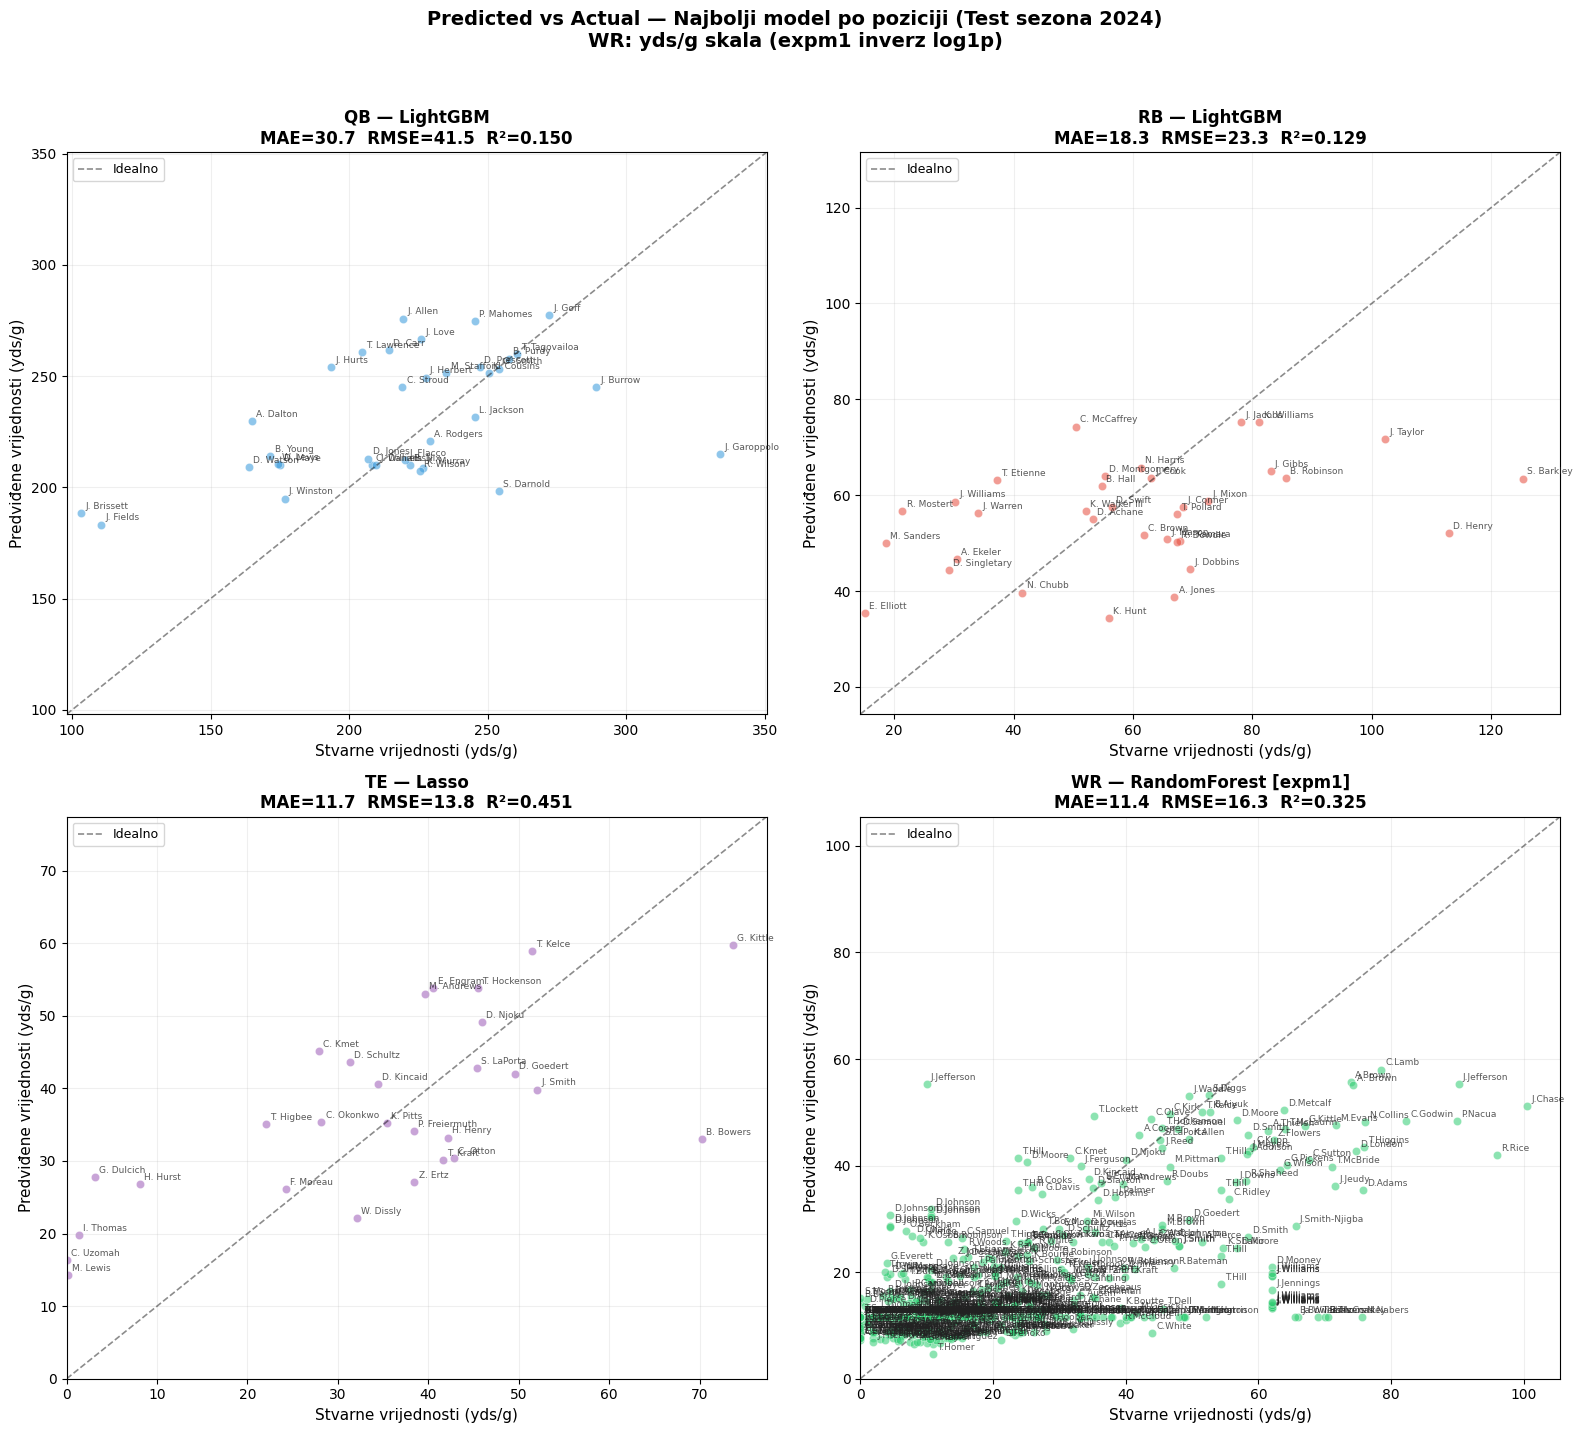

In [19]:

# ── Predicted vs Actual — scatter plotovi za sve pozicije ─────────────────
# WR: predikcije i stvarne vrijednosti se konvertuju expm1() → yds/g skala.
# Sve 4 pozicije su tako direktno usporedive na istoj skali (yds/g).

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

COLORS = {'QB': '#3498db', 'RB': '#e74c3c', 'TE': '#9b59b6', 'WR': '#2ecc71'}

# Dohvati imena igrača iz test seta (sezona 2024)
PLAYER_COL = {
    'QB': 'Player', 'RB': 'Player', 'TE': 'Player', 'WR': 'receiver_player_name'
}
SEASON_COL = {
    'QB': 'Season', 'RB': 'Season', 'TE': 'Season', 'WR': 'season'
}

player_names = {}
for pos in ['QB', 'RB', 'TE', 'WR']:
    pcol = PLAYER_COL[pos]
    scol = SEASON_COL[pos]
    test_df = lagged[pos][lagged[pos][scol] == 2024]
    player_names[pos] = test_df[pcol].values

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, pos in zip(axes.flat, ['QB', 'RB', 'TE', 'WR']):
    _, X_te, _, y_te = processed[pos]
    best_name, best_model = best_models[pos]
    preds = best_model.predict(X_te)
    names = player_names[pos]

    if pos == 'WR':
        y_actual = np.expm1(y_te.values)
        y_pred   = np.expm1(preds)
        scale_note = ' [expm1]'
    else:
        y_actual = y_te.values
        y_pred   = preds
        scale_note = ''

    mae  = test_results[pos].loc[best_name, 'MAE']
    rmse = test_results[pos].loc[best_name, 'RMSE']
    r2   = test_results[pos].loc[best_name, 'R2']

    ax.scatter(y_actual, y_pred, color=COLORS[pos], alpha=0.55, s=35,
               edgecolor='white', linewidth=0.4)

    lo = min(y_actual.min(), y_pred.min()) * 0.95
    hi = max(y_actual.max(), y_pred.max()) * 1.05
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.45, linewidth=1.2, label='Idealno')

    # Dodaj imena igrača na tačke
    for x, y, name in zip(y_actual, y_pred, names):
        # Skrati ime: prvo slovo + prezime (npr. "P. Mahomes")
        parts = str(name).split()
        short = f'{parts[0][0]}. {" ".join(parts[1:])}' if len(parts) > 1 else name
        ax.annotate(
            short,
            xy=(x, y),
            xytext=(3, 3),
            textcoords='offset points',
            fontsize=6.5,
            alpha=0.75,
            color='#222222',
        )

    ax.set_xlabel('Stvarne vrijednosti (yds/g)', fontsize=11)
    ax.set_ylabel('Predviđene vrijednosti (yds/g)', fontsize=11)
    ax.set_title(
        f'{pos} — {best_name}{scale_note}\n'
        f'MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

fig.suptitle(
    'Predicted vs Actual — Najbolji model po poziciji (Test sezona 2024)\n'
    'WR: yds/g skala (expm1 inverz log1p)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()


In [20]:

# ══════════════════════════════════════════════════════════════════════════════
# ── Kalibracija evaluacije — Cross-Year Hold-Out (Walk-Forward)  ─────────────
# ══════════════════════════════════════════════════════════════════════════════
#
# POTPUNO ČISTA temporalna validacija — NULA data leakage:
#   Fold 1:  Train 1979–2020 → Test 2021
#   Fold 2:  Train 1979–2021 → Test 2022
#   Fold 3:  Train 1979–2022 → Test 2023
#   Fold 4:  Train 1979–2023 → Test 2024
#
# Na SVAKOM foldu (4 puta):
#   1. Imputer  — fituje se SAMO na train podacima tog folda
#   2. Scaler   — fituje se SAMO na train podacima tog folda
#   3. GridSearchCV — hiperparametri se biraju SAMO iz train podacima tog folda
#   4. Model    — trenira se SAMO na train podacima tog folda
#   → Model NIKADA ne vidi podatke iz test sezone — ni direktno ni indirektno

import ast, copy
import numpy as np, pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

FOLDS = [
    {'name': 'Fold 1', 'train_end': 2020, 'test_year': 2021},
    {'name': 'Fold 2', 'train_end': 2021, 'test_year': 2022},
    {'name': 'Fold 3', 'train_end': 2022, 'test_year': 2023},
    {'name': 'Fold 4', 'train_end': 2023, 'test_year': 2024},
]

POS_SCOL    = {'QB': 'Season', 'RB': 'Season', 'TE': 'Season', 'WR': 'season'}
POS_ID_COLS = {
    'QB': ['Player', 'Season', 'Team'],
    'RB': ['Player', 'Season', 'Team'],
    'TE': ['Player', 'Season', 'Team'],
    'WR': ['receiver_player_name', 'season', 'posteam'],
}

# Isti model configs kao i ranije — ali se GridSearchCV radi SVJEŽE po foldu
CAL_MODEL_CONFIGS = {
    'LinearRegression': {
        'model': LinearRegression(),
        'params': {},
    },
    'Ridge': {
        'model': Ridge(),
        'params': {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    },
    'Lasso': {
        'model': Lasso(max_iter=10000),
        'params': {'alpha': [0.001, 0.01, 0.1, 1.0]},
    },
    'ElasticNet': {
        'model': ElasticNet(max_iter=10000),
        'params': {'alpha': [0.01, 0.1, 1.0], 'l1_ratio': [0.1, 0.5, 0.9]},
    },
    'KNeighbors': {
        'model': KNeighborsRegressor(),
        'params': {'n_neighbors': [3, 5, 7, 9, 11, 15], 'weights': ['uniform', 'distance']},
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5],
        },
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.8, 1.0],
        },
    },
    'LightGBM': {
        'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'num_leaves': [15, 31, 63],
        },
    },
}

# ── Walk-forward petlja ──────────────────────────────────────────────────
cal_records = []       # svi rezultati po (pos, model, fold)
cal_best_per_pos = {}  # {pos: model_name sa najnižim avg RMSE kroz 4 folda}
cal_best_params = {}   # {(pos, model, fold): best_params} — za transparentnost

for pos in ['QB', 'RB', 'TE', 'WR']:
    scol      = POS_SCOL[pos]
    id_cols   = POS_ID_COLS[pos]
    df_full   = lagged[pos]
    is_wr     = (pos == 'WR')
    feat_cols = [c for c in df_full.columns if c not in id_cols + ['target']]

    print(f'\n{"═"*90}')
    print(f'  {pos} — Kalibracija evaluacije (Cross-Year Hold-Out)')
    if is_wr:
        print(f'  [WR: sve metrike na originalnoj yds/g skali — expm1 inverz]')
    print(f'{"═"*90}')

    model_avg_rmse = {}

    for model_name, mcfg in CAL_MODEL_CONFIGS.items():
        fold_mae, fold_rmse, fold_r2 = [], [], []
        fold_details = []

        for fold in FOLDS:
            train_end = fold['train_end']
            test_year = fold['test_year']

            # ══ STRIKTNI TEMPORALNI SPLIT ════════════════════════
            tr_mask = df_full[scol] <= train_end
            te_mask = df_full[scol] == test_year

            tr_df = df_full[tr_mask]
            te_df = df_full[te_mask]

            if len(te_df) == 0:
                fold_details.append(('N/A', 'N/A', 'N/A', {}))
                continue

            X_tr = tr_df[feat_cols].copy()
            y_tr = tr_df['target'].copy()
            X_te = te_df[feat_cols].copy()
            y_te = te_df['target'].copy()

            # ── 1. lag2 NaN → 0 ─────────────────────────────────
            lag2_c = [c for c in X_tr.columns if c.endswith('_lag2')]
            X_tr[lag2_c] = X_tr[lag2_c].fillna(0)
            X_te[lag2_c] = X_te[lag2_c].fillna(0)

            # ── 2. Imputacija — fit SAMO na train ovog folda ─────
            imp = SimpleImputer(strategy='median')
            X_tr_i = pd.DataFrame(imp.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
            X_te_i = pd.DataFrame(imp.transform(X_te),     columns=X_te.columns, index=X_te.index)

            # ── 3. Skaliranje — fit SAMO na train ovog folda ─────
            bin_c = [c for c in BINARY_COLS if c in X_tr.columns]
            num_c = [c for c in X_tr.columns if c not in bin_c]
            sc    = StandardScaler()
            X_tr_i[num_c] = sc.fit_transform(X_tr_i[num_c])
            X_te_i[num_c] = sc.transform(X_te_i[num_c])

            # ── 4. GridSearchCV — SAMO na train ovog folda ───────
            #    Hiperparametri se biraju isključivo iz podataka ≤ train_end
            tscv_fold = TimeSeriesSplit(n_splits=min(5, max(2, len(X_tr_i) // 50)))

            if mcfg['params']:
                grid = GridSearchCV(
                    copy.deepcopy(mcfg['model']),
                    mcfg['params'],
                    cv=tscv_fold,
                    scoring='neg_mean_absolute_error',
                    n_jobs=-1,
                    refit=True,
                )
                grid.fit(X_tr_i, y_tr)
                best_model = grid.best_estimator_
                best_p     = grid.best_params_
            else:
                best_model = copy.deepcopy(mcfg['model'])
                best_model.fit(X_tr_i, y_tr)
                best_p = {}

            # ── 5. Predikcija na test sezoni ─────────────────────
            preds = best_model.predict(X_te_i)

            # ── 6. WR inverz transformacija ──────────────────────
            if is_wr:
                y_ev = np.expm1(y_te.values)
                p_ev = np.expm1(preds)
            else:
                y_ev = y_te.values
                p_ev = preds

            mae  = mean_absolute_error(y_ev, p_ev)
            rmse = np.sqrt(mean_squared_error(y_ev, p_ev))
            r2   = r2_score(y_ev, p_ev)

            fold_mae.append(mae)
            fold_rmse.append(rmse)
            fold_r2.append(r2)
            fold_details.append((mae, rmse, r2, best_p))

            cal_records.append(dict(
                pos=pos, model=model_name,
                fold=fold['name'], train_end=train_end, test_year=test_year,
                n_train=len(tr_df), n_test=len(te_df),
                mae=mae, rmse=rmse, r2=r2,
                best_params=str(best_p),
            ))
            cal_best_params[(pos, model_name, fold['name'])] = best_p

        # Prosjeci preko 4 folda
        avg_mae  = np.mean(fold_mae)  if fold_mae  else np.nan
        avg_rmse = np.mean(fold_rmse) if fold_rmse else np.nan
        avg_r2   = np.mean(fold_r2)   if fold_r2   else np.nan
        model_avg_rmse[model_name] = avg_rmse

    # Ispis svega za ovu poziciju
    print(f'\n  {"Model":<20} │', end='')
    for f in FOLDS:
        print(f'  {f["name"]+" ("+str(f["test_year"])+")":>18}', end='')
    print(f'  │ {"AvgMAE":>8} {"AvgRMSE":>9} {"AvgR²":>7}')
    print(f'  {"─"*130}')

    for model_name in CAL_MODEL_CONFIGS.keys():
        sub = [r for r in cal_records if r['pos'] == pos and r['model'] == model_name]
        if not sub:
            continue
        row_str = f'  {model_name:<20} │'
        maes, rmses, r2s = [], [], []
        for f in FOLDS:
            match = [r for r in sub if r['test_year'] == f['test_year']]
            if match:
                row_str += f'  {match[0]["rmse"]:>7.2f} (R²={match[0]["r2"]:>6.3f})'
                maes.append(match[0]['mae'])
                rmses.append(match[0]['rmse'])
                r2s.append(match[0]['r2'])
            else:
                row_str += f'  {"N/A":>18}'

        avg_m  = np.mean(maes) if maes else np.nan
        avg_rm = np.mean(rmses) if rmses else np.nan
        avg_r  = np.mean(r2s) if r2s else np.nan
        row_str += f'  │ {avg_m:>8.3f} {avg_rm:>9.3f} {avg_r:>7.3f}'
        print(row_str)

    best_model_name = min(model_avg_rmse, key=model_avg_rmse.get)
    cal_best_per_pos[pos] = best_model_name
    print(f'\n  ★ Najbolji model ({pos}): {best_model_name}  |  Avg RMSE = {model_avg_rmse[best_model_name]:.3f}')

    # Prikaz kako se hiperparametri mijenjaju po foldu za best model
    print(f'\n  Hiperparametri {best_model_name} po foldu:')
    for f in FOLDS:
        key = (pos, best_model_name, f['name'])
        p = cal_best_params.get(key, {})
        print(f'    {f["name"]} (train ≤{f["train_end"]}): {p if p else "N/A (nema hiperparametara)"}')

cal_df = pd.DataFrame(cal_records)

# ══════════════════════════════════════════════════════════════════════════════
# ── Sumarni pregled + usporedba sa single-year testom ────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
print(f'\n\n{"═"*105}')
print(f'  SUMARNI PREGLED — Kalibracija (svježi GridSearchCV po foldu) vs Single-Year (2024) Test')
print(f'{"═"*105}')
print(f'  {"Pos":<5} {"Kal. pobjednik":<22} {"AvgMAE":>8} {"AvgRMSE":>9} {"AvgR²":>7}'
      f'  │  {"Single-2024 pobjednik":<22} {"RMSE_2024":>10}  │  {"Isti?":>5}')
print(f'  {"─"*105}')

for pos in ['QB', 'RB', 'TE', 'WR']:
    sub = cal_df[cal_df['pos'] == pos].groupby('model').agg(
        avg_mae=('mae','mean'), avg_rmse=('rmse','mean'), avg_r2=('r2','mean')
    )
    cal_best = sub['avg_rmse'].idxmin()
    cal_row  = sub.loc[cal_best]

    s24_name = best_models[pos][0]
    s24_rmse = test_results[pos].loc[s24_name, 'RMSE']

    same = '✓ DA' if cal_best == s24_name else '✗ NE'
    print(f'  {pos:<5} {cal_best:<22} {cal_row["avg_mae"]:>8.3f} {cal_row["avg_rmse"]:>9.3f} '
          f'{cal_row["avg_r2"]:>7.3f}  │  {s24_name:<22} {s24_rmse:>10.3f}  │  {same:>5}')

print(f'\n  PIPELINE PO FOLDU (potpuno svježe, 0 leakage):')
print(f'    1. Imputer  → fit na train ≤ t')
print(f'    2. Scaler   → fit na train ≤ t')
print(f'    3. GridSearchCV → hiperparametri birani SAMO iz train ≤ t')
print(f'    4. Model    → treniran SAMO na train ≤ t')
print(f'    5. Predict  → test = sezona t+1')
print(f'\nKalibracija evaluacije završena — 4 potpuno nezavisna treninga.')



══════════════════════════════════════════════════════════════════════════════════════════
  QB — Kalibracija evaluacije (Cross-Year Hold-Out)
══════════════════════════════════════════════════════════════════════════════════════════

  Model                │       Fold 1 (2021)       Fold 2 (2022)       Fold 3 (2023)       Fold 4 (2024)  │   AvgMAE   AvgRMSE   AvgR²
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  LinearRegression     │    68.39 (R²=-0.001)    43.00 (R²=-0.115)    69.65 (R²= 0.074)    82.48 (R²=-2.365)  │   44.506    65.881  -0.602
  Ridge                │    68.22 (R²= 0.004)    35.42 (R²= 0.244)    72.98 (R²=-0.016)    44.07 (R²= 0.039)  │   38.714    55.171   0.068
  Lasso                │    69.07 (R²=-0.020)    34.96 (R²= 0.263)    71.67 (R²= 0.020)    43.98 (R²= 0.043)  │   38.426    54.919   0.076
  ElasticNet           │    69.18 (R²=-0.024)    36.27 (R²= 0.207)    75.05 (R²

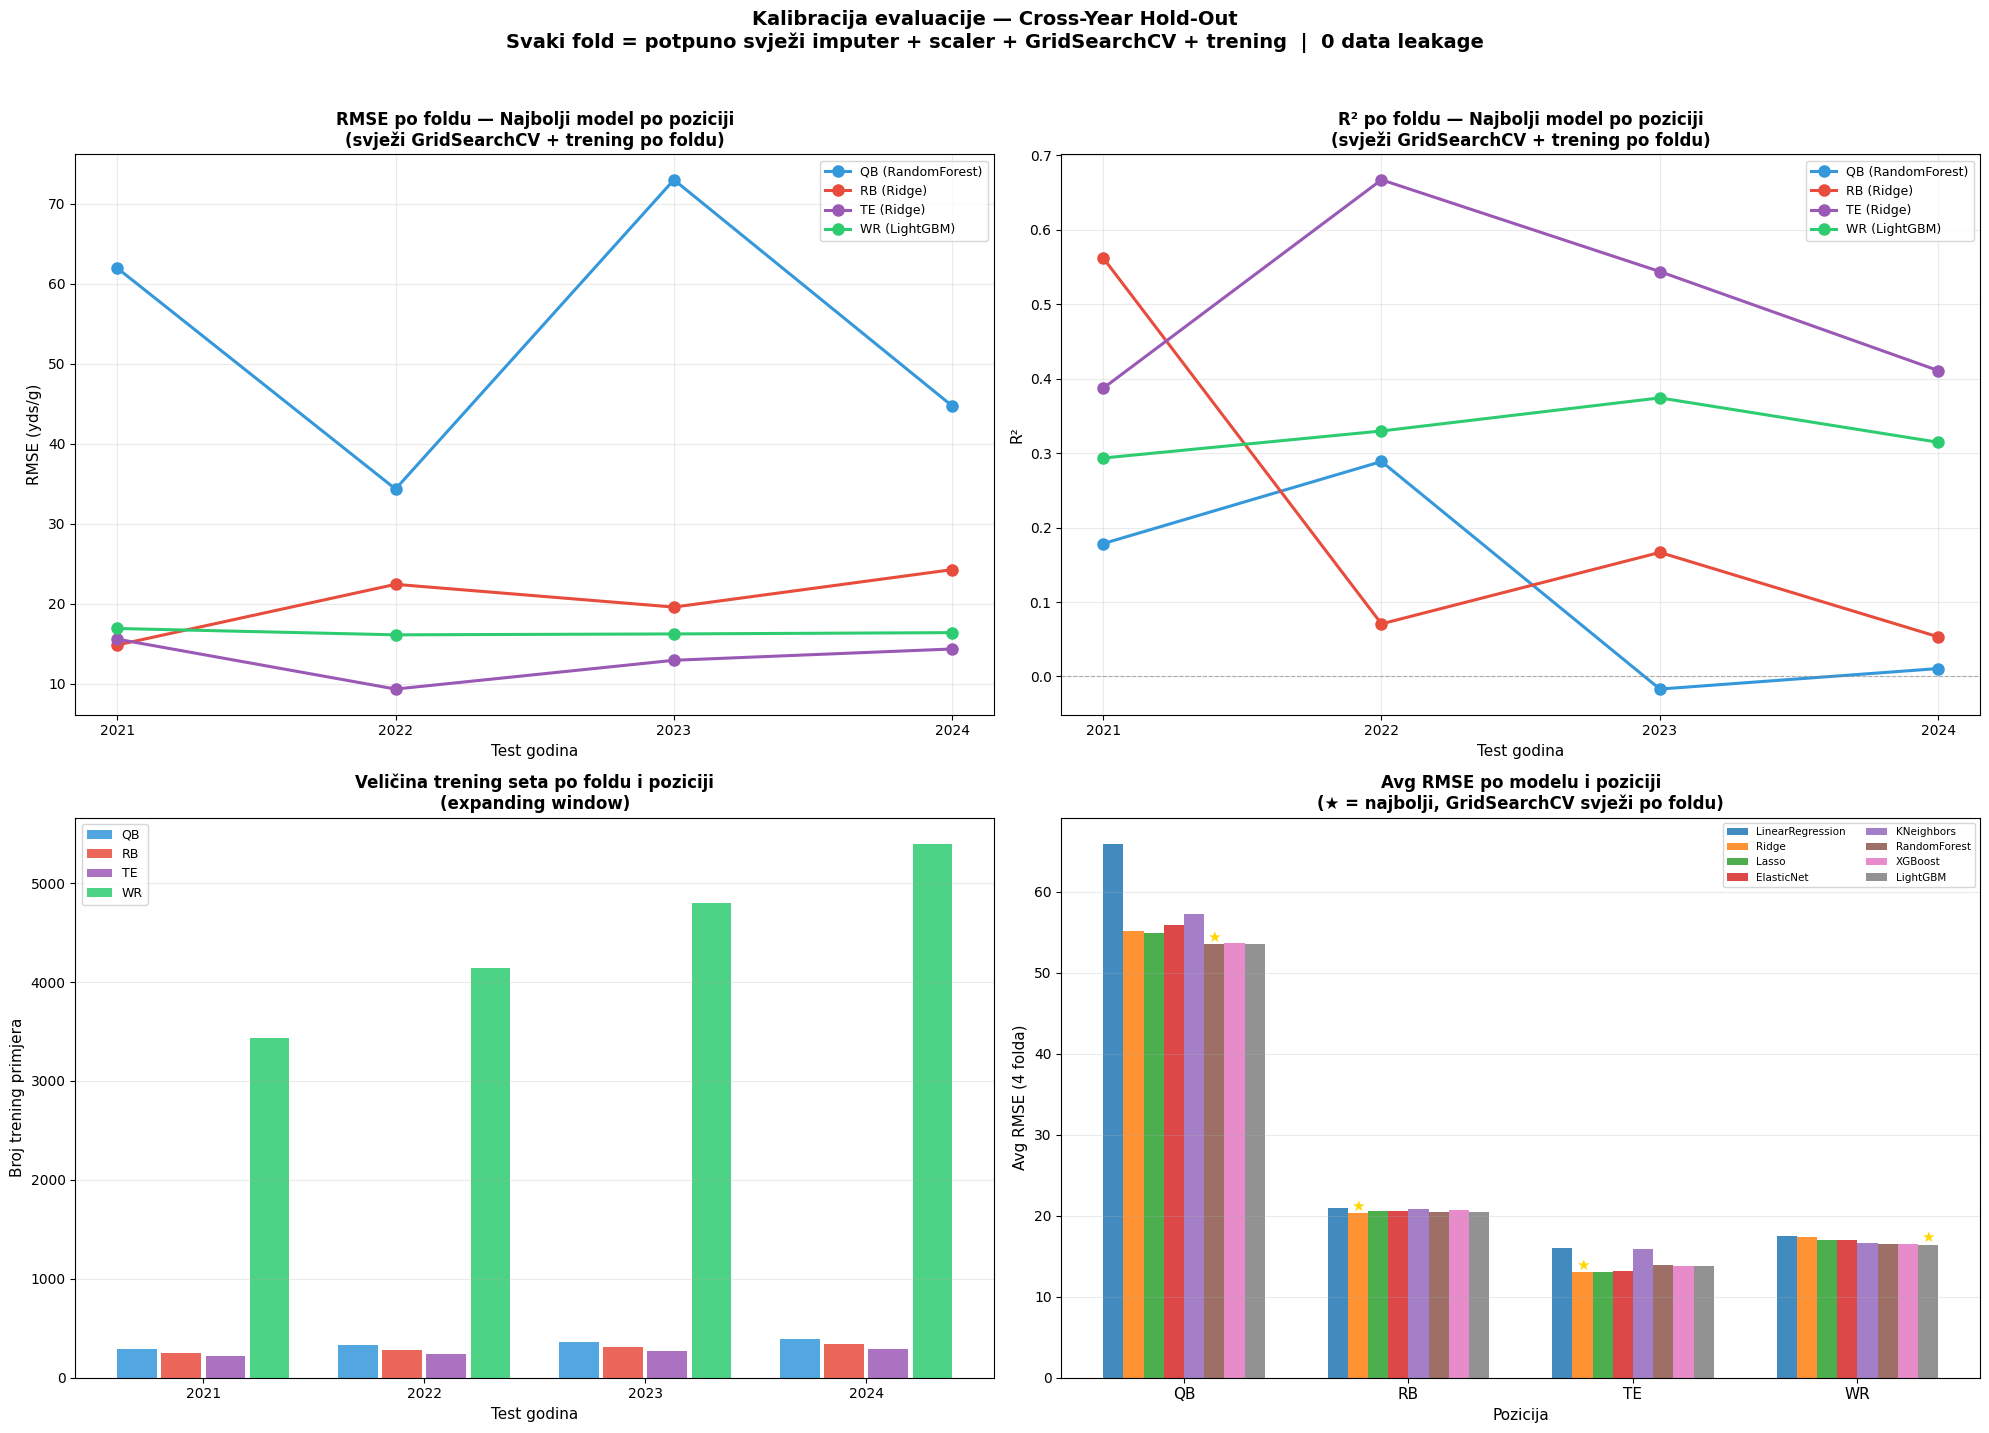


═══════════════════════════════════════════════════════════════════════════════════════════════
DETALJNI REZULTATI PO POZICIJI I FOLDU (sa parametrima)
═══════════════════════════════════════════════════════════════════════════════════════════════

QB  (★ Najbolji avg RMSE: RandomForest)
Train/test veličine:   2021: train=295, test=33  2022: train=328, test=31  2023: train=359, test=33  2024: train=392, test=35
                  RMSE_2021  RMSE_2022  RMSE_2023  RMSE_2024  R²_2021  R²_2022  R²_2023  R²_2024  AvgRMSE  AvgR2
model                                                                                                           
ElasticNet            69.18      36.27      75.05      43.26   -0.024    0.207   -0.075    0.074   55.942  0.046
KNeighbors            67.54      41.67      78.20      41.63    0.024   -0.047   -0.167    0.143   57.261 -0.012
Lasso                 69.07      34.96      71.67      43.98   -0.020    0.263    0.020    0.043   54.919  0.076
LightGBM           

In [21]:

# ══════════════════════════════════════════════════════════════════════════════
# ── Vizualizacija kalibracije — 4 nezavisna treninga ─────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np

POSITIONS = ['QB', 'RB', 'TE', 'WR']
colors_pos = {'QB': '#3498db', 'RB': '#e74c3c', 'TE': '#9b59b6', 'WR': '#2ecc71'}

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# ── 1. RMSE po foldu — najbolji model po poziciji ────────────────────────
ax = axes[0, 0]
for pos in POSITIONS:
    best_m = cal_best_per_pos[pos]
    sub = cal_df[(cal_df['pos'] == pos) & (cal_df['model'] == best_m)].sort_values('test_year')
    ax.plot(sub['test_year'], sub['rmse'], marker='o', linewidth=2.2, markersize=8,
            label=f'{pos} ({best_m})', color=colors_pos[pos])
ax.set_xlabel('Test godina', fontsize=11)
ax.set_ylabel('RMSE (yds/g)', fontsize=11)
ax.set_title('RMSE po foldu — Najbolji model po poziciji\n(svježi GridSearchCV + trening po foldu)', fontsize=12, fontweight='bold')
ax.set_xticks([2021, 2022, 2023, 2024])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# ── 2. R² po foldu — najbolji model po poziciji ─────────────────────────
ax = axes[0, 1]
for pos in POSITIONS:
    best_m = cal_best_per_pos[pos]
    sub = cal_df[(cal_df['pos'] == pos) & (cal_df['model'] == best_m)].sort_values('test_year')
    ax.plot(sub['test_year'], sub['r2'], marker='o', linewidth=2.2, markersize=8,
            label=f'{pos} ({best_m})', color=colors_pos[pos])
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Test godina', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('R² po foldu — Najbolji model po poziciji\n(svježi GridSearchCV + trening po foldu)', fontsize=12, fontweight='bold')
ax.set_xticks([2021, 2022, 2023, 2024])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# ── 3. Train size po foldu ───────────────────────────────────────────────
ax = axes[1, 0]
for pos in POSITIONS:
    best_m = cal_best_per_pos[pos]
    sub = cal_df[(cal_df['pos'] == pos) & (cal_df['model'] == best_m)].sort_values('test_year')
    ax.bar([y + {'QB': -0.3, 'RB': -0.1, 'TE': 0.1, 'WR': 0.3}[pos] for y in sub['test_year']],
           sub['n_train'], width=0.18, label=f'{pos}', color=colors_pos[pos], alpha=0.85)
ax.set_xlabel('Test godina', fontsize=11)
ax.set_ylabel('Broj trening primjera', fontsize=11)
ax.set_title('Veličina trening seta po foldu i poziciji\n(expanding window)', fontsize=12, fontweight='bold')
ax.set_xticks([2021, 2022, 2023, 2024])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25, axis='y')

# ── 4. Avg RMSE bar chart — svi modeli, grupirano po poziciji ───────────
ax = axes[1, 1]
cal_summary = cal_df.groupby(['pos', 'model']).agg(avg_rmse=('rmse','mean')).reset_index()
model_names = list(CAL_MODEL_CONFIGS.keys())
x = np.arange(len(POSITIONS))
width = 0.09
for i, m_name in enumerate(model_names):
    vals = []
    for pos in POSITIONS:
        row = cal_summary[(cal_summary['pos'] == pos) & (cal_summary['model'] == m_name)]
        vals.append(row['avg_rmse'].values[0] if len(row) else 0)
    offset = (i - len(model_names)/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=m_name, alpha=0.85)
    for j, pos in enumerate(POSITIONS):
        if m_name == cal_best_per_pos[pos]:
            ax.text(x[j] + offset, vals[j] + 0.3, '★', ha='center', fontsize=11, color='gold')
ax.set_xlabel('Pozicija', fontsize=11)
ax.set_ylabel('Avg RMSE (4 folda)', fontsize=11)
ax.set_title('Avg RMSE po modelu i poziciji\n(★ = najbolji, GridSearchCV svježi po foldu)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(POSITIONS, fontsize=11)
ax.legend(fontsize=7.5, ncol=2)
ax.grid(True, alpha=0.25, axis='y')

plt.suptitle('Kalibracija evaluacije — Cross-Year Hold-Out\n'
             'Svaki fold = potpuno svježi imputer + scaler + GridSearchCV + trening  |  0 data leakage',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Detaljna tabela po poziciji ──────────────────────────────────────────
print('\n' + '═'*95)
print('DETALJNI REZULTATI PO POZICIJI I FOLDU (sa parametrima)')
print('═'*95)

for pos in POSITIONS:
    sub = cal_df[cal_df['pos'] == pos]
    best_m = cal_best_per_pos[pos]

    rmse_piv = sub.pivot_table(index='model', columns='test_year', values='rmse').round(2)
    r2_piv   = sub.pivot_table(index='model', columns='test_year', values='r2').round(3)
    ntr_piv  = sub.pivot_table(index='model', columns='test_year', values='n_train', aggfunc='first')
    nte_piv  = sub.pivot_table(index='model', columns='test_year', values='n_test',  aggfunc='first')

    rmse_piv.columns = [f'RMSE_{y}' for y in rmse_piv.columns]
    r2_piv.columns   = [f'R²_{y}'   for y in r2_piv.columns]

    avg = sub.groupby('model').agg(AvgRMSE=('rmse','mean'), AvgR2=('r2','mean')).round(3)
    combined = pd.concat([rmse_piv, r2_piv, avg], axis=1)

    print(f'\n{pos}  (★ Najbolji avg RMSE: {best_m})')
    print(f'Train/test veličine: ', end='')
    for yr in [2021, 2022, 2023, 2024]:
        if yr in ntr_piv.columns:
            n = int(ntr_piv[yr].iloc[0])
            nt = int(nte_piv[yr].iloc[0])
            print(f'  {yr}: train={n}, test={nt}', end='')
    print()
    print(combined.to_string())

    # Hiperparametri po foldu za best model
    print(f'\n  Parametri {best_m} po foldu:')
    for _, row in sub[sub['model'] == best_m].sort_values('test_year').iterrows():
        print(f'    Train≤{row["train_end"]} → Test {row["test_year"]}: {row["best_params"]}')


QB   (LightGBM            ) — računanje SHAP ...
      Explainer: TreeExplainer | base value: 236.4695 | SHAP shape: (35, 74)
RB   (LightGBM            ) — računanje SHAP ...
      Explainer: TreeExplainer | base value: 58.3609 | SHAP shape: (34, 38)
TE   (Lasso               ) — računanje SHAP ...
      Explainer: LinearExplainer | base value: 42.1990 | SHAP shape: (28, 48)
WR   (RandomForest        ) — računanje SHAP ...
      Explainer: TreeExplainer | base value: 2.7497 | SHAP shape: (558, 87)

SHAP vrijednosti izračunate za sve pozicije.


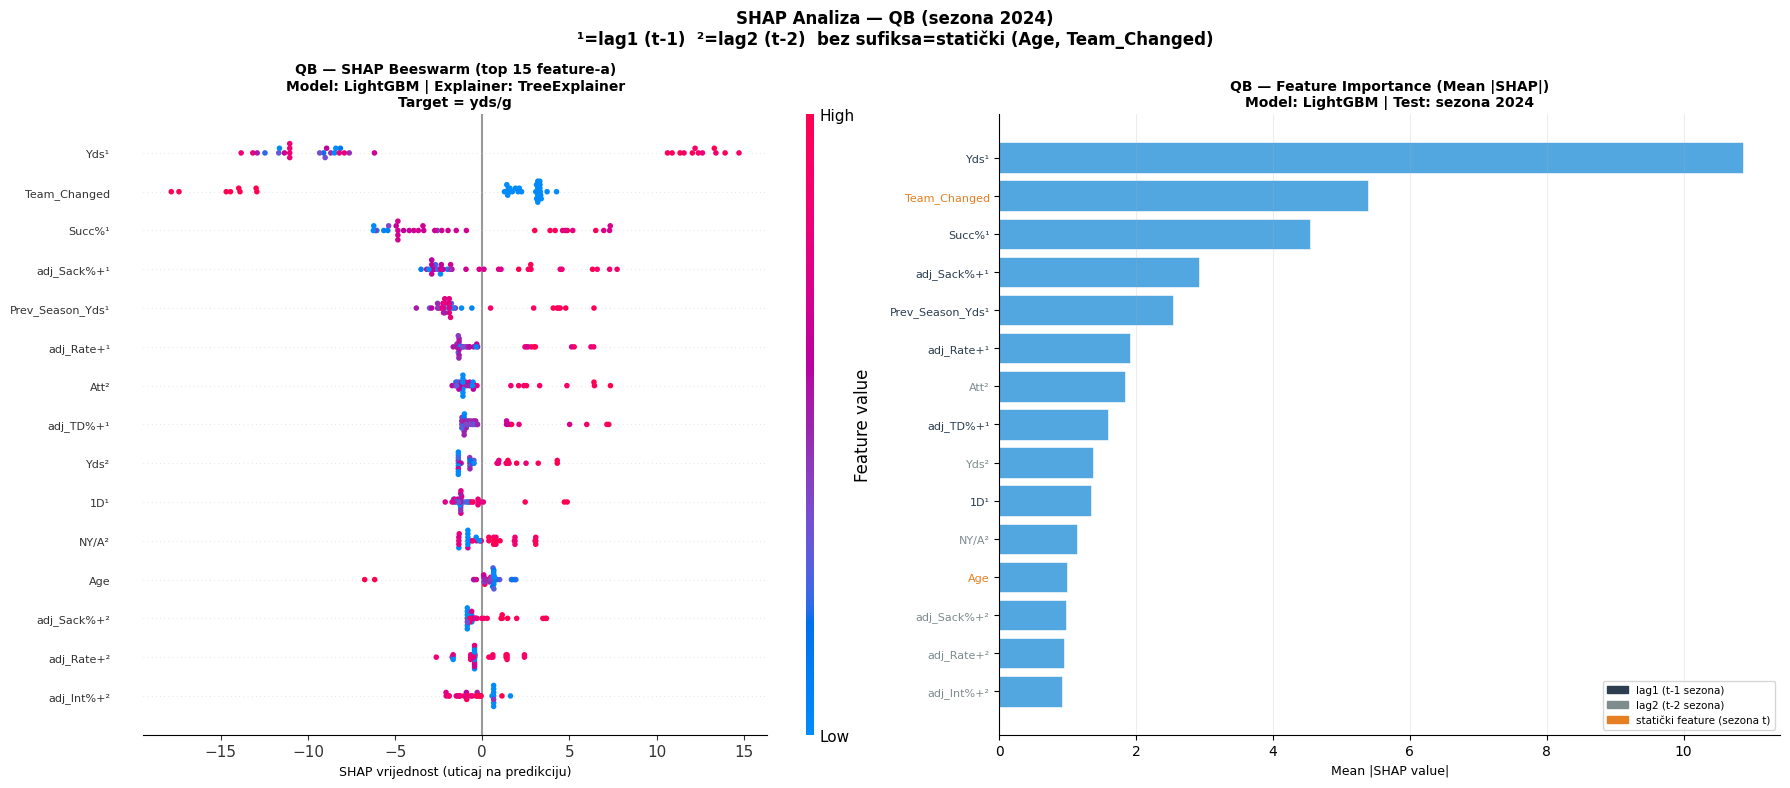


──────────────────────────────────────────────────────────────────────
QB — Top 10 najvažnijih feature-a (Mean |SHAP|):
──────────────────────────────────────────────────────────────────────
    #  Feature                                        Mean |SHAP|  Avg vrednost u testu
  ----------------------------------------------------------------------------------
    1. Yds¹                                              10.86621               -0.4438
    2. Team_Changed                                       5.38293                0.2286
    3. Succ%¹                                             4.54541               -0.2050
    4. adj_Sack%+¹                                        2.91499               -0.0496
    5. Prev_Season_Yds¹                                   2.53463               -0.2201
    6. adj_Rate+¹                                         1.91309                0.0412
    7. Att²                                               1.82946               -0.0396
    8. adj_TD%+¹   

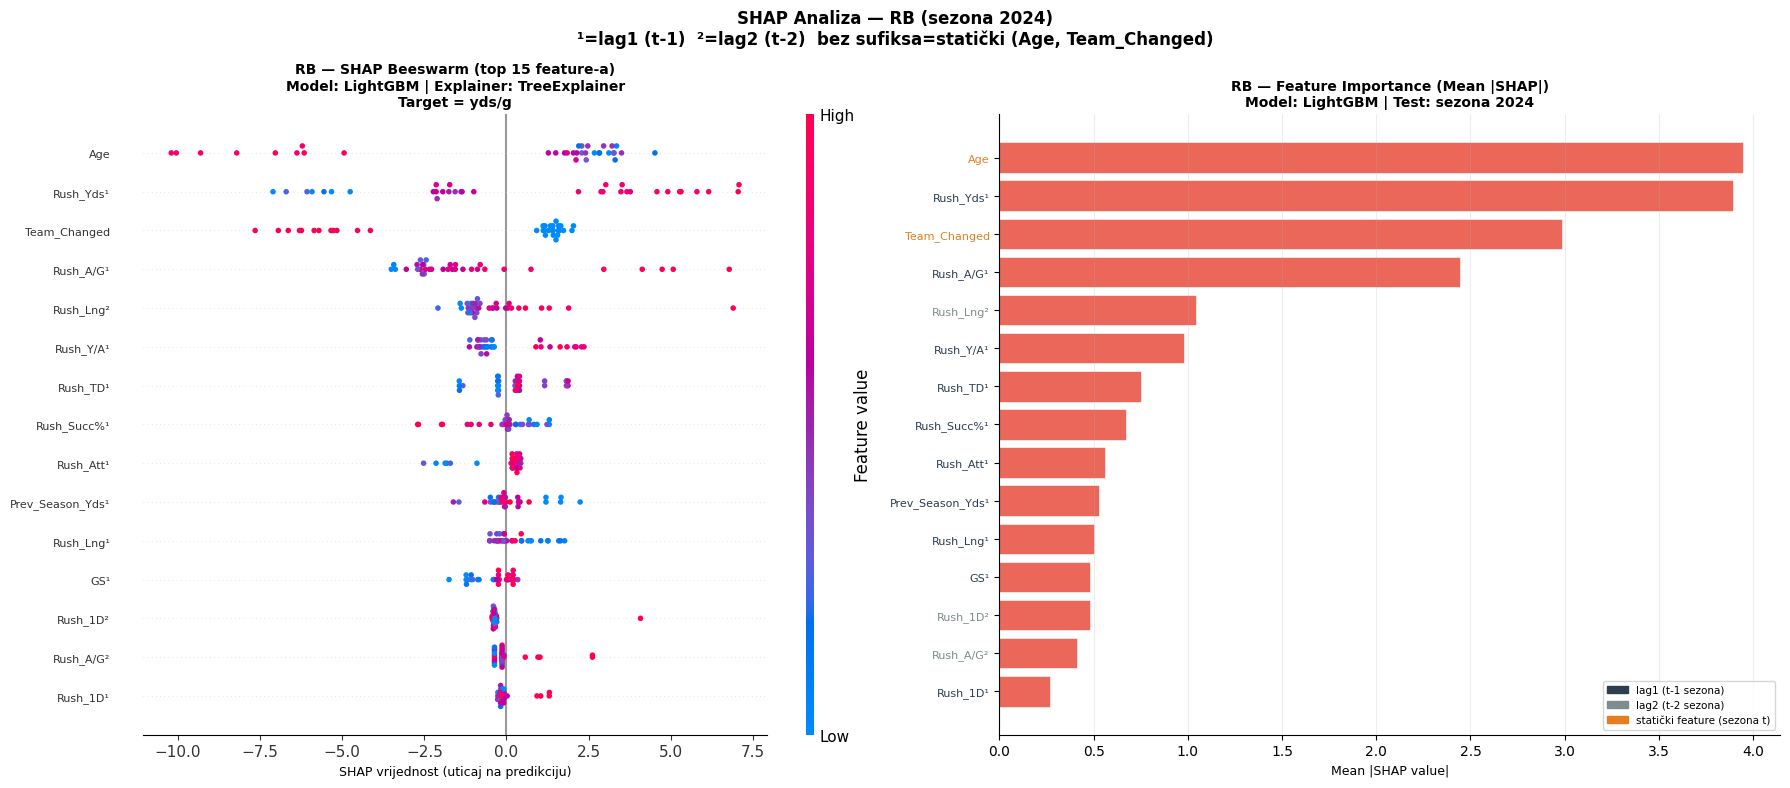


──────────────────────────────────────────────────────────────────────
RB — Top 10 najvažnijih feature-a (Mean |SHAP|):
──────────────────────────────────────────────────────────────────────
    #  Feature                                        Mean |SHAP|  Avg vrednost u testu
  ----------------------------------------------------------------------------------
    1. Age                                                3.94525                0.0234
    2. Rush_Yds¹                                          3.89500               -0.1933
    3. Team_Changed                                       2.98641                0.3529
    4. Rush_A/G¹                                          2.44540               -0.2741
    5. Rush_Lng²                                          1.04164                0.2422
    6. Rush_Y/A¹                                          0.97770               -0.1216
    7. Rush_TD¹                                           0.75376               -0.0126
    8. Rush_Succ%¹ 

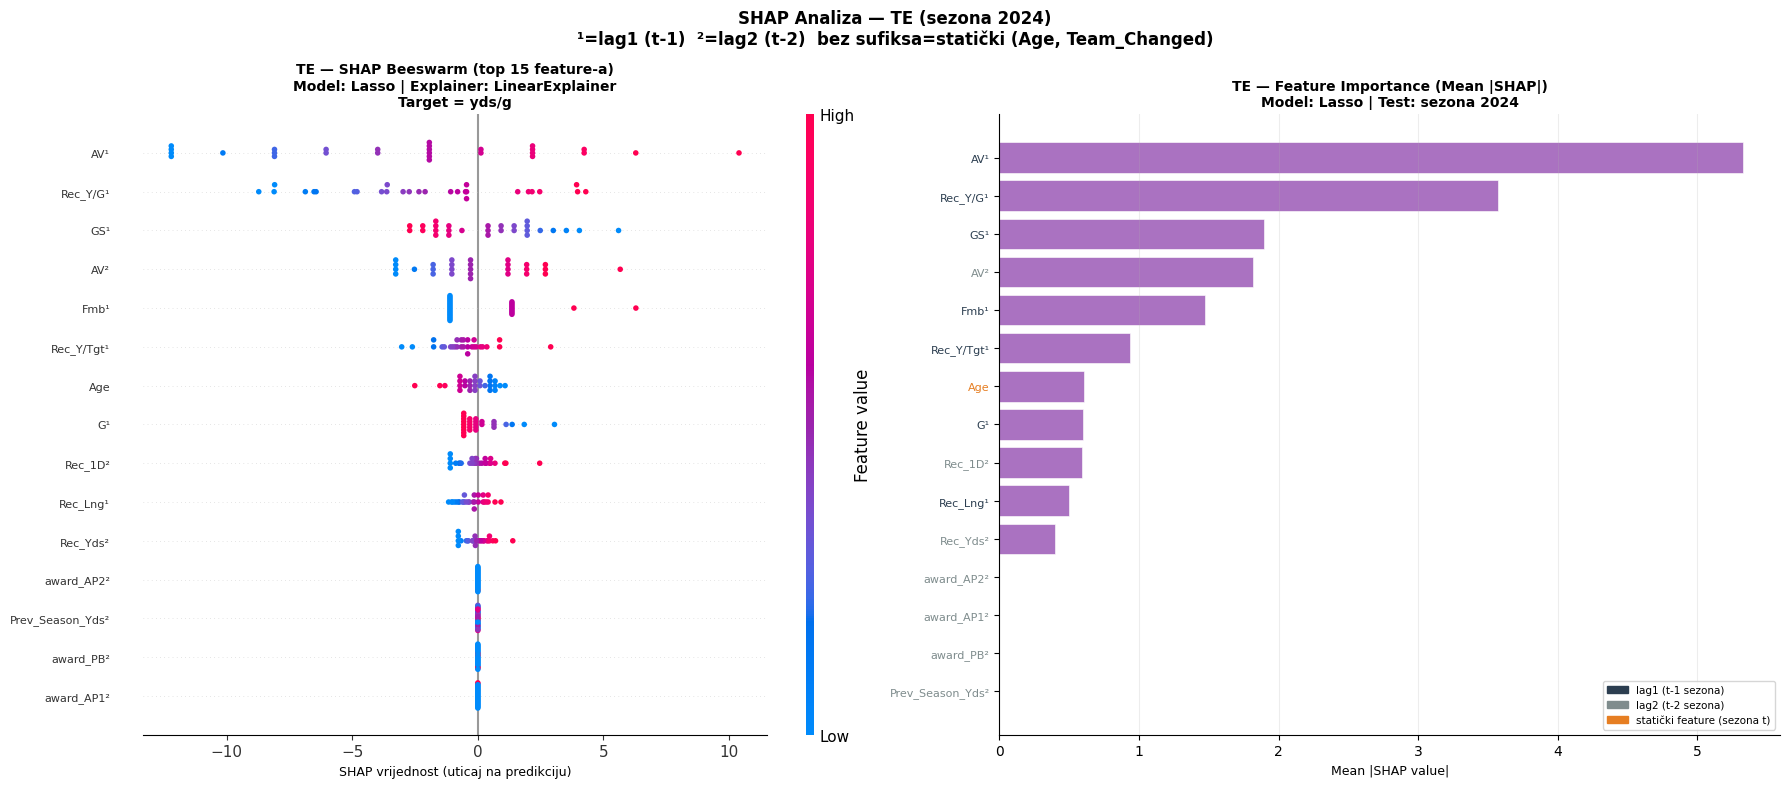


──────────────────────────────────────────────────────────────────────
TE — Top 10 najvažnijih feature-a (Mean |SHAP|):
──────────────────────────────────────────────────────────────────────
    #  Feature                                        Mean |SHAP|  Avg vrednost u testu
  ----------------------------------------------------------------------------------
    1. AV¹                                                5.32564               -0.3166
    2. Rec_Y/G¹                                           3.56859               -0.3749
    3. GS¹                                                1.89667               -0.1562
    4. AV²                                                1.81924                0.0124
    5. Fmb¹                                               1.47274                0.0871
    6. Rec_Y/Tgt¹                                         0.93377               -0.3031
    7. Age                                                0.60881                0.1643
    8. G¹          

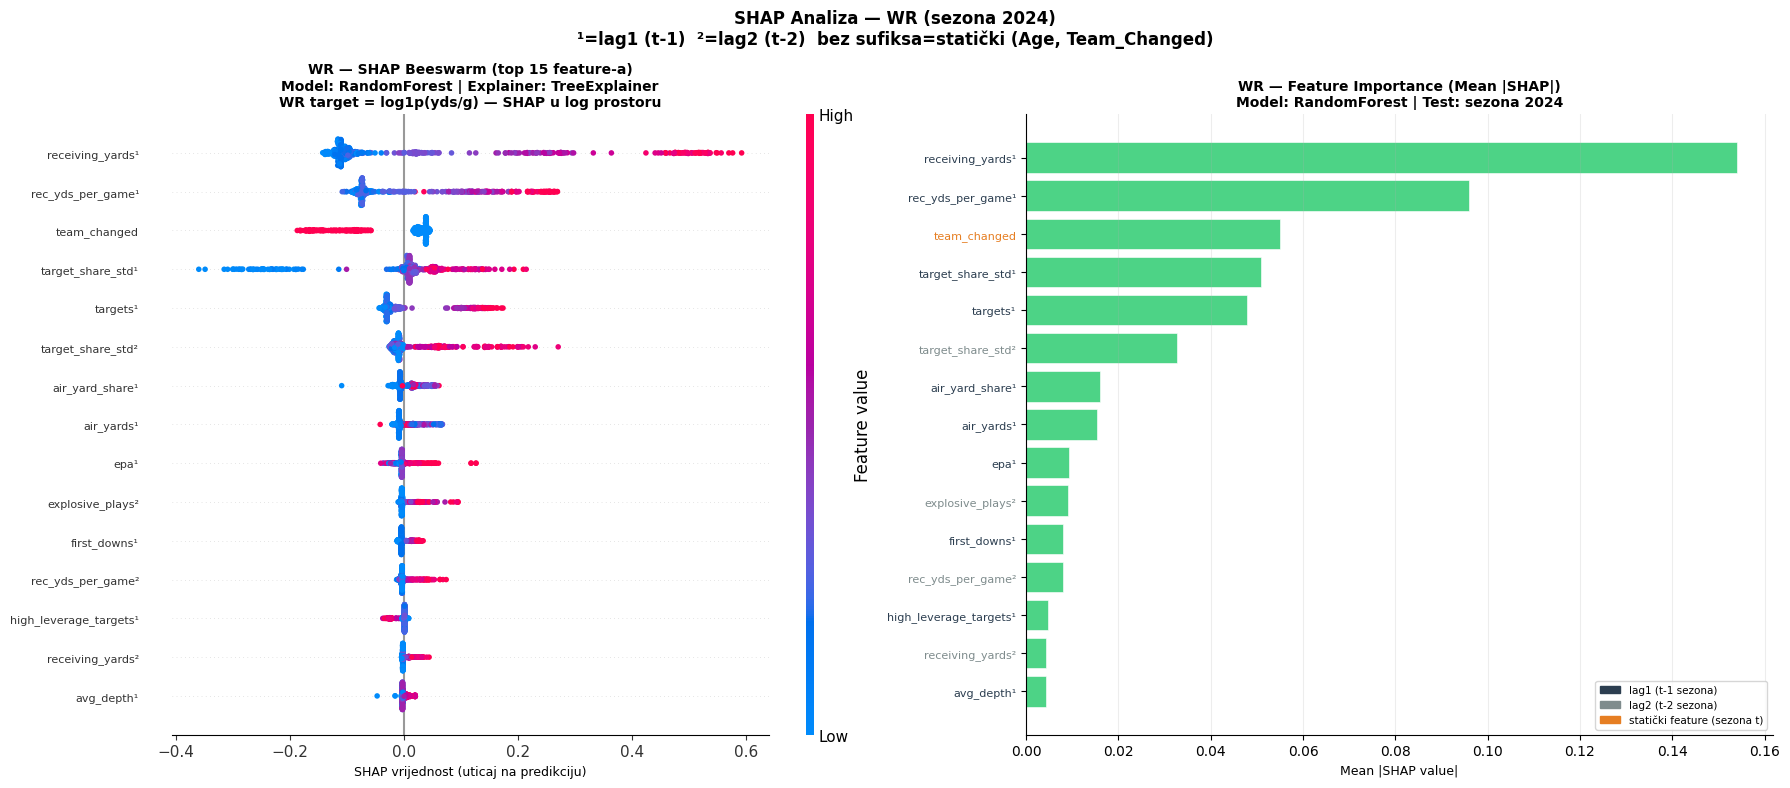


──────────────────────────────────────────────────────────────────────
WR — Top 10 najvažnijih feature-a (Mean |SHAP|):
──────────────────────────────────────────────────────────────────────
    #  Feature                                        Mean |SHAP|  Avg vrednost u testu
  ----------------------------------------------------------------------------------
    1. receiving_yards¹                                   0.15402                0.0909
    2. rec_yds_per_game¹                                  0.09592               -0.0001
    3. team_changed                                       0.05502                0.2599
    4. target_share_std¹                                  0.05097               -0.0839
    5. targets¹                                           0.04793                0.0862
    6. target_share_std²                                  0.03270                0.2283
    7. air_yard_share¹                                    0.01604                0.1458
    8. air_yards¹  

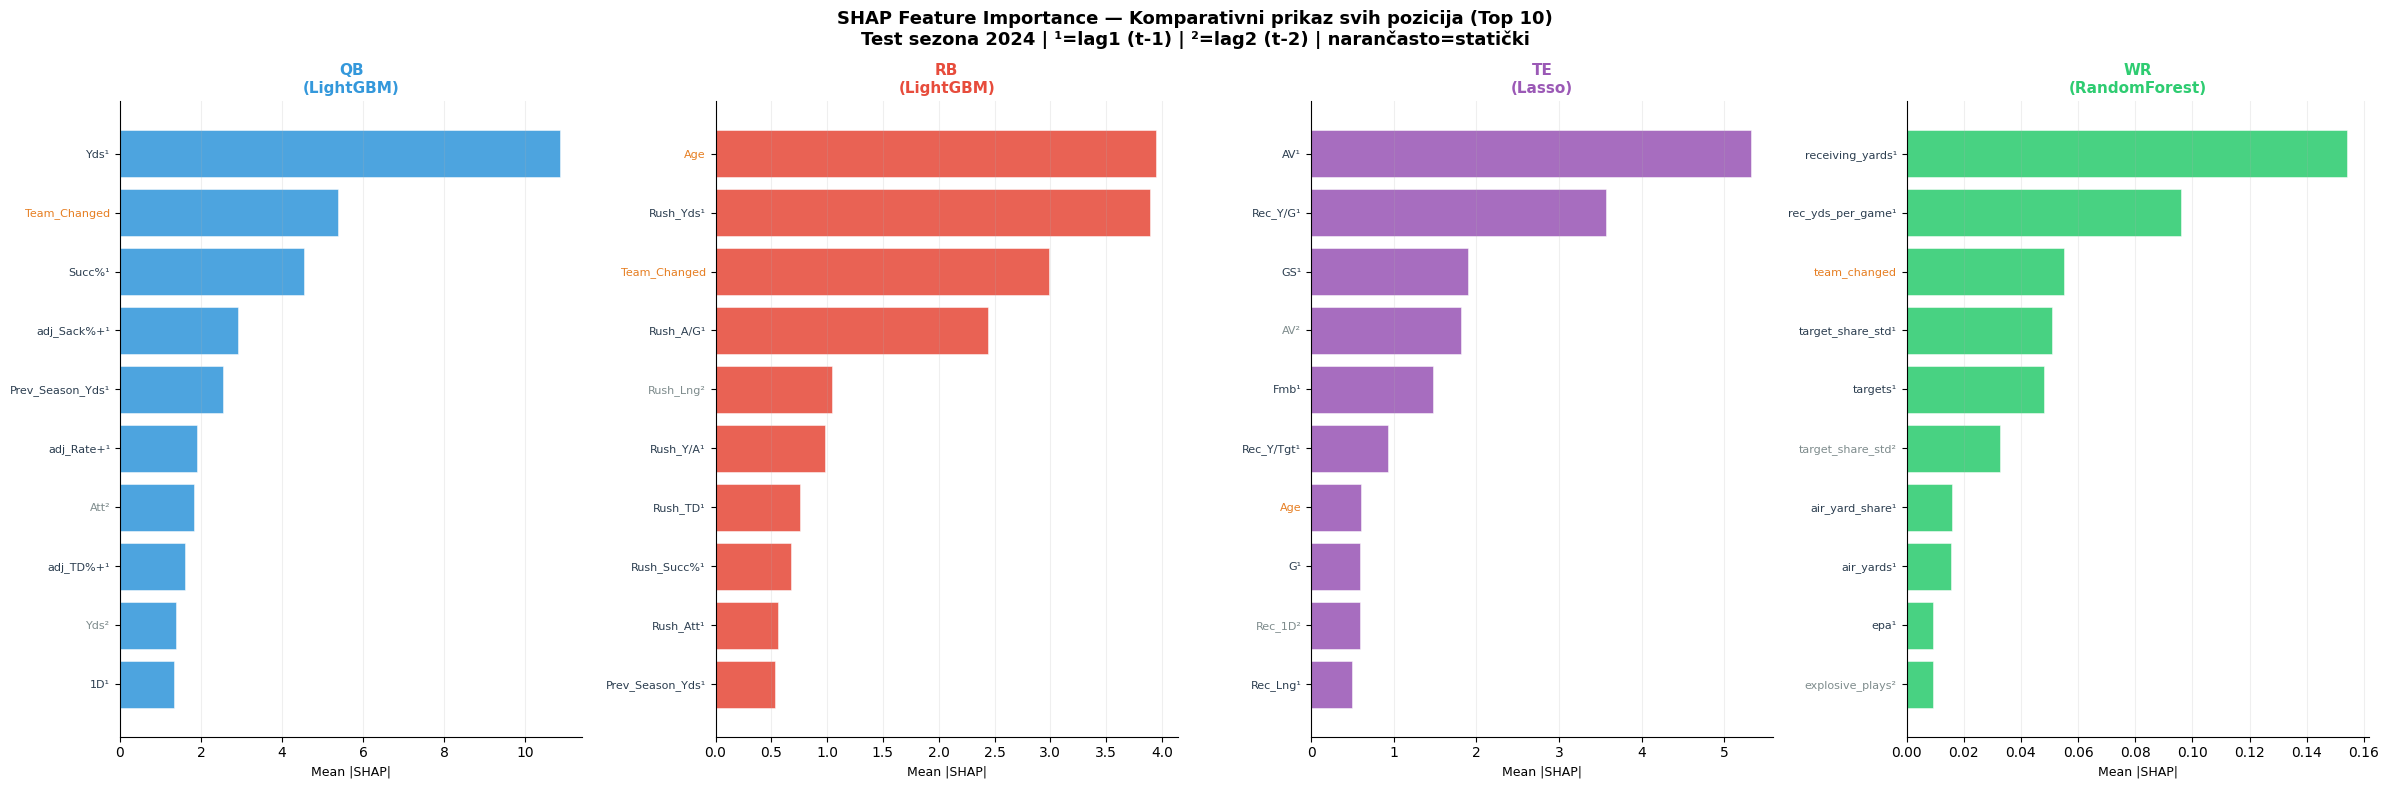


SHAP analiza završena za sve pozicije.


In [22]:

# ══════════════════════════════════════════════════════════════════════════════
# ── SHAP Analiza važnosti feature-a — po poziciji ────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
#
# Koristi se best model po poziciji (iz best_models).
# Explainer se bira automatski prema tipu modela:
#   • RandomForest / XGBoost / LightGBM → shap.TreeExplainer (brz, tačan)
#   • Ridge / Lasso / ElasticNet / LinearRegression → shap.LinearExplainer
#   • KNeighbors (ili drugi) → shap.KernelExplainer (uzorak 100 redova bg)
#
# SHAP vrijednosti se računaju na X_test (sezona 2024) za sve pozicije.
# WR: SHAP vrijednosti su u log1p prostoru (model je treniran na log1p(yds/g)).
#     →  pozitivne SHAP vrijednosti povećavaju predikciju u log prostoru,
#        što znači eksponencijalno veći pravi yds/g. Ovo je norma za log-target modele.

import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

shap.initjs()

TOP_N = 15          # Broj prikazanih feature-a
POSITIONS_ORDER = ['QB', 'RB', 'TE', 'WR']
COLORS_POS = {'QB': '#3498db', 'RB': '#e74c3c', 'TE': '#9b59b6', 'WR': '#2ecc71'}

# ── Računanje SHAP vrijednosti ────────────────────────────────────────────
shap_data = {}   # {pos: {'vals': ndarray, 'X_te': df, 'base': float, 'explainer_type': str}}

for pos in POSITIONS_ORDER:
    best_name, best_model = best_models[pos]
    X_tr, X_te, y_tr, y_te = processed[pos]

    print(f'{pos:<4} ({best_name:<20}) — računanje SHAP ...')

    if isinstance(best_model, (RandomForestRegressor, XGBRegressor, LGBMRegressor)):
        explainer      = shap.TreeExplainer(best_model)
        sv             = explainer.shap_values(X_te)
        base           = float(np.atleast_1d(explainer.expected_value)[0])
        exp_type       = 'TreeExplainer'

    elif isinstance(best_model, (LinearRegression, Ridge, Lasso, ElasticNet)):
        explainer      = shap.LinearExplainer(best_model, X_tr)
        sv             = explainer.shap_values(X_te)
        base           = float(explainer.expected_value)
        exp_type       = 'LinearExplainer'

    else:
        # KNN ili nepoznat tip → KernelExplainer na uzorku 150 train redova
        bg             = shap.sample(X_tr, min(150, len(X_tr)), random_state=42)
        explainer      = shap.KernelExplainer(best_model.predict, bg)
        sv             = explainer.shap_values(X_te, nsamples=200)
        base           = float(explainer.expected_value)
        exp_type       = 'KernelExplainer'

    shap_data[pos] = {
        'vals':          sv,
        'X_te':          X_te,
        'base':          base,
        'explainer_type': exp_type,
        'best_name':     best_name,
    }
    print(f'      Explainer: {exp_type} | base value: {base:.4f} | SHAP shape: {sv.shape}')

print('\nSHAP vrijednosti izračunate za sve pozicije.')


# ══════════════════════════════════════════════════════════════════════════════
# ── 1. Beeswarm plotovi — po poziciji (top 15 feature-a) ─────────────────────
# ══════════════════════════════════════════════════════════════════════════════

def shorten_feat_name(name):
    """Skraćuje ime feature-a radi čitljivosti osi."""
    name = name.replace('_lag1', '¹').replace('_lag2', '²')
    return name

for pos in POSITIONS_ORDER:
    d        = shap_data[pos]
    sv       = d['vals']
    X_te_df  = d['X_te']
    bname    = d['best_name']
    etype    = d['explainer_type']
    is_wr    = (pos == 'WR')

    feat_names   = [shorten_feat_name(c) for c in X_te_df.columns]
    mean_abs     = np.abs(sv).mean(axis=0)
    top_idx      = np.argsort(mean_abs)[::-1][:TOP_N]
    top_feats    = [feat_names[i] for i in top_idx]
    sv_top       = sv[:, top_idx]
    X_top        = X_te_df.iloc[:, top_idx]
    X_top.columns = top_feats

    fig, (ax_bee, ax_bar) = plt.subplots(1, 2, figsize=(18, 8))

    # ── Beeswarm ──────────────────────────────────────────────────────────
    plt.sca(ax_bee)
    shap.summary_plot(
        sv_top,
        X_top,
        feature_names=top_feats,
        plot_size=None,
        show=False,
        color_bar=True,
    )
    ax_bee.set_title(
        f'{pos} — SHAP Beeswarm (top {TOP_N} feature-a)\n'
        f'Model: {bname} | Explainer: {etype}\n'
        f'{"WR target = log1p(yds/g) — SHAP u log prostoru" if is_wr else "Target = yds/g"}',
        fontsize=10, fontweight='bold'
    )
    ax_bee.set_xlabel('SHAP vrijednost (uticaj na predikciju)', fontsize=9)
    ax_bee.tick_params(axis='y', labelsize=8)

    # ── Bar chart (mean |SHAP|) ───────────────────────────────────────────
    vals_sorted  = mean_abs[top_idx][::-1]
    feats_sorted = top_feats[::-1]
    colors_bar   = [COLORS_POS[pos]] * TOP_N

    ax_bar.barh(range(TOP_N), vals_sorted, color=colors_bar, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax_bar.set_yticks(range(TOP_N))
    ax_bar.set_yticklabels(feats_sorted, fontsize=8)
    ax_bar.set_xlabel('Mean |SHAP value|', fontsize=9)
    ax_bar.set_title(
        f'{pos} — Feature Importance (Mean |SHAP|)\n'
        f'Model: {bname} | Test: sezona 2024',
        fontsize=10, fontweight='bold'
    )
    ax_bar.grid(True, alpha=0.22, axis='x')
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)

    # Označi lag1 vs lag2 vs statički
    for i, fn in enumerate(feats_sorted):
        marker = '¹' if fn.endswith('¹') else ('²' if fn.endswith('²') else ' ')
        color  = '#2c3e50' if marker == '¹' else ('#7f8c8d' if marker == '²' else '#e67e22')
        ax_bar.get_yticklabels()[i].set_color(color)

    # Legenda
    leg = [
        mpatches.Patch(color='#2c3e50', label='lag1 (t-1 sezona)'),
        mpatches.Patch(color='#7f8c8d', label='lag2 (t-2 sezona)'),
        mpatches.Patch(color='#e67e22', label='statički feature (sezona t)'),
    ]
    ax_bar.legend(handles=leg, fontsize=7.5, loc='lower right')

    fig.suptitle(
        f'SHAP Analiza — {pos} (sezona 2024)\n'
        f'¹=lag1 (t-1)  ²=lag2 (t-2)  bez sufiksa=statički (Age, Team_Changed)',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    # ── Tekstualni ispis top 10 ───────────────────────────────────────────
    print(f'\n{"─"*70}')
    print(f'{pos} — Top 10 najvažnijih feature-a (Mean |SHAP|):')
    print(f'{"─"*70}')
    print(f'  {"#":>3}  {"Feature":<45} {"Mean |SHAP|":>12}  {"Avg vrednost u testu":>20}')
    print(f'  {"-"*82}')
    for rank, i in enumerate(top_idx[:10], 1):
        orig_col  = X_te_df.columns[i]
        short     = feat_names[i]
        m_shap    = mean_abs[i]
        avg_val   = float(X_te_df.iloc[:, i].mean())
        print(f'  {rank:>3}. {short:<45} {m_shap:>12.5f}  {avg_val:>20.4f}')


# ══════════════════════════════════════════════════════════════════════════════
# ── 2. Komparativni prikaz — Top 10 feature-a sve 4 pozicije ─────────────────
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 4, figsize=(24, 8))

for ax, pos in zip(axes, POSITIONS_ORDER):
    d       = shap_data[pos]
    sv      = d['vals']
    X_te_df = d['X_te']
    bname   = d['best_name']

    feat_names = [shorten_feat_name(c) for c in X_te_df.columns]
    mean_abs   = np.abs(sv).mean(axis=0)
    top_idx    = np.argsort(mean_abs)[::-1][:10]
    vals_s     = mean_abs[top_idx][::-1]
    feats_s    = [feat_names[i] for i in top_idx][::-1]

    bars = ax.barh(range(10), vals_s, color=COLORS_POS[pos], alpha=0.88,
                   edgecolor='white', linewidth=0.4)
    ax.set_yticks(range(10))
    ax.set_yticklabels(feats_s, fontsize=8)
    ax.set_xlabel('Mean |SHAP|', fontsize=9)
    ax.set_title(f'{pos}\n({bname})', fontsize=11, fontweight='bold',
                 color=COLORS_POS[pos])
    ax.grid(True, alpha=0.2, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for i, fn in enumerate(feats_s):
        color = '#2c3e50' if fn.endswith('¹') else ('#7f8c8d' if fn.endswith('²') else '#e67e22')
        ax.get_yticklabels()[i].set_color(color)

fig.suptitle(
    'SHAP Feature Importance — Komparativni prikaz svih pozicija (Top 10)\n'
    'Test sezona 2024 | ¹=lag1 (t-1) | ²=lag2 (t-2) | narančasto=statički',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('\nSHAP analiza završena za sve pozicije.')


QB — treniranje po foldu (LightGBM) ...
  → 132 predikcija prikupljeno (4 folda)
RB — treniranje po foldu (LightGBM) ...
  → 130 predikcija prikupljeno (4 folda)
TE — treniranje po foldu (Lasso) ...
  → 107 predikcija prikupljeno (4 folda)
WR — treniranje po foldu (RandomForest) ...
  → 2515 predikcija prikupljeno (4 folda)


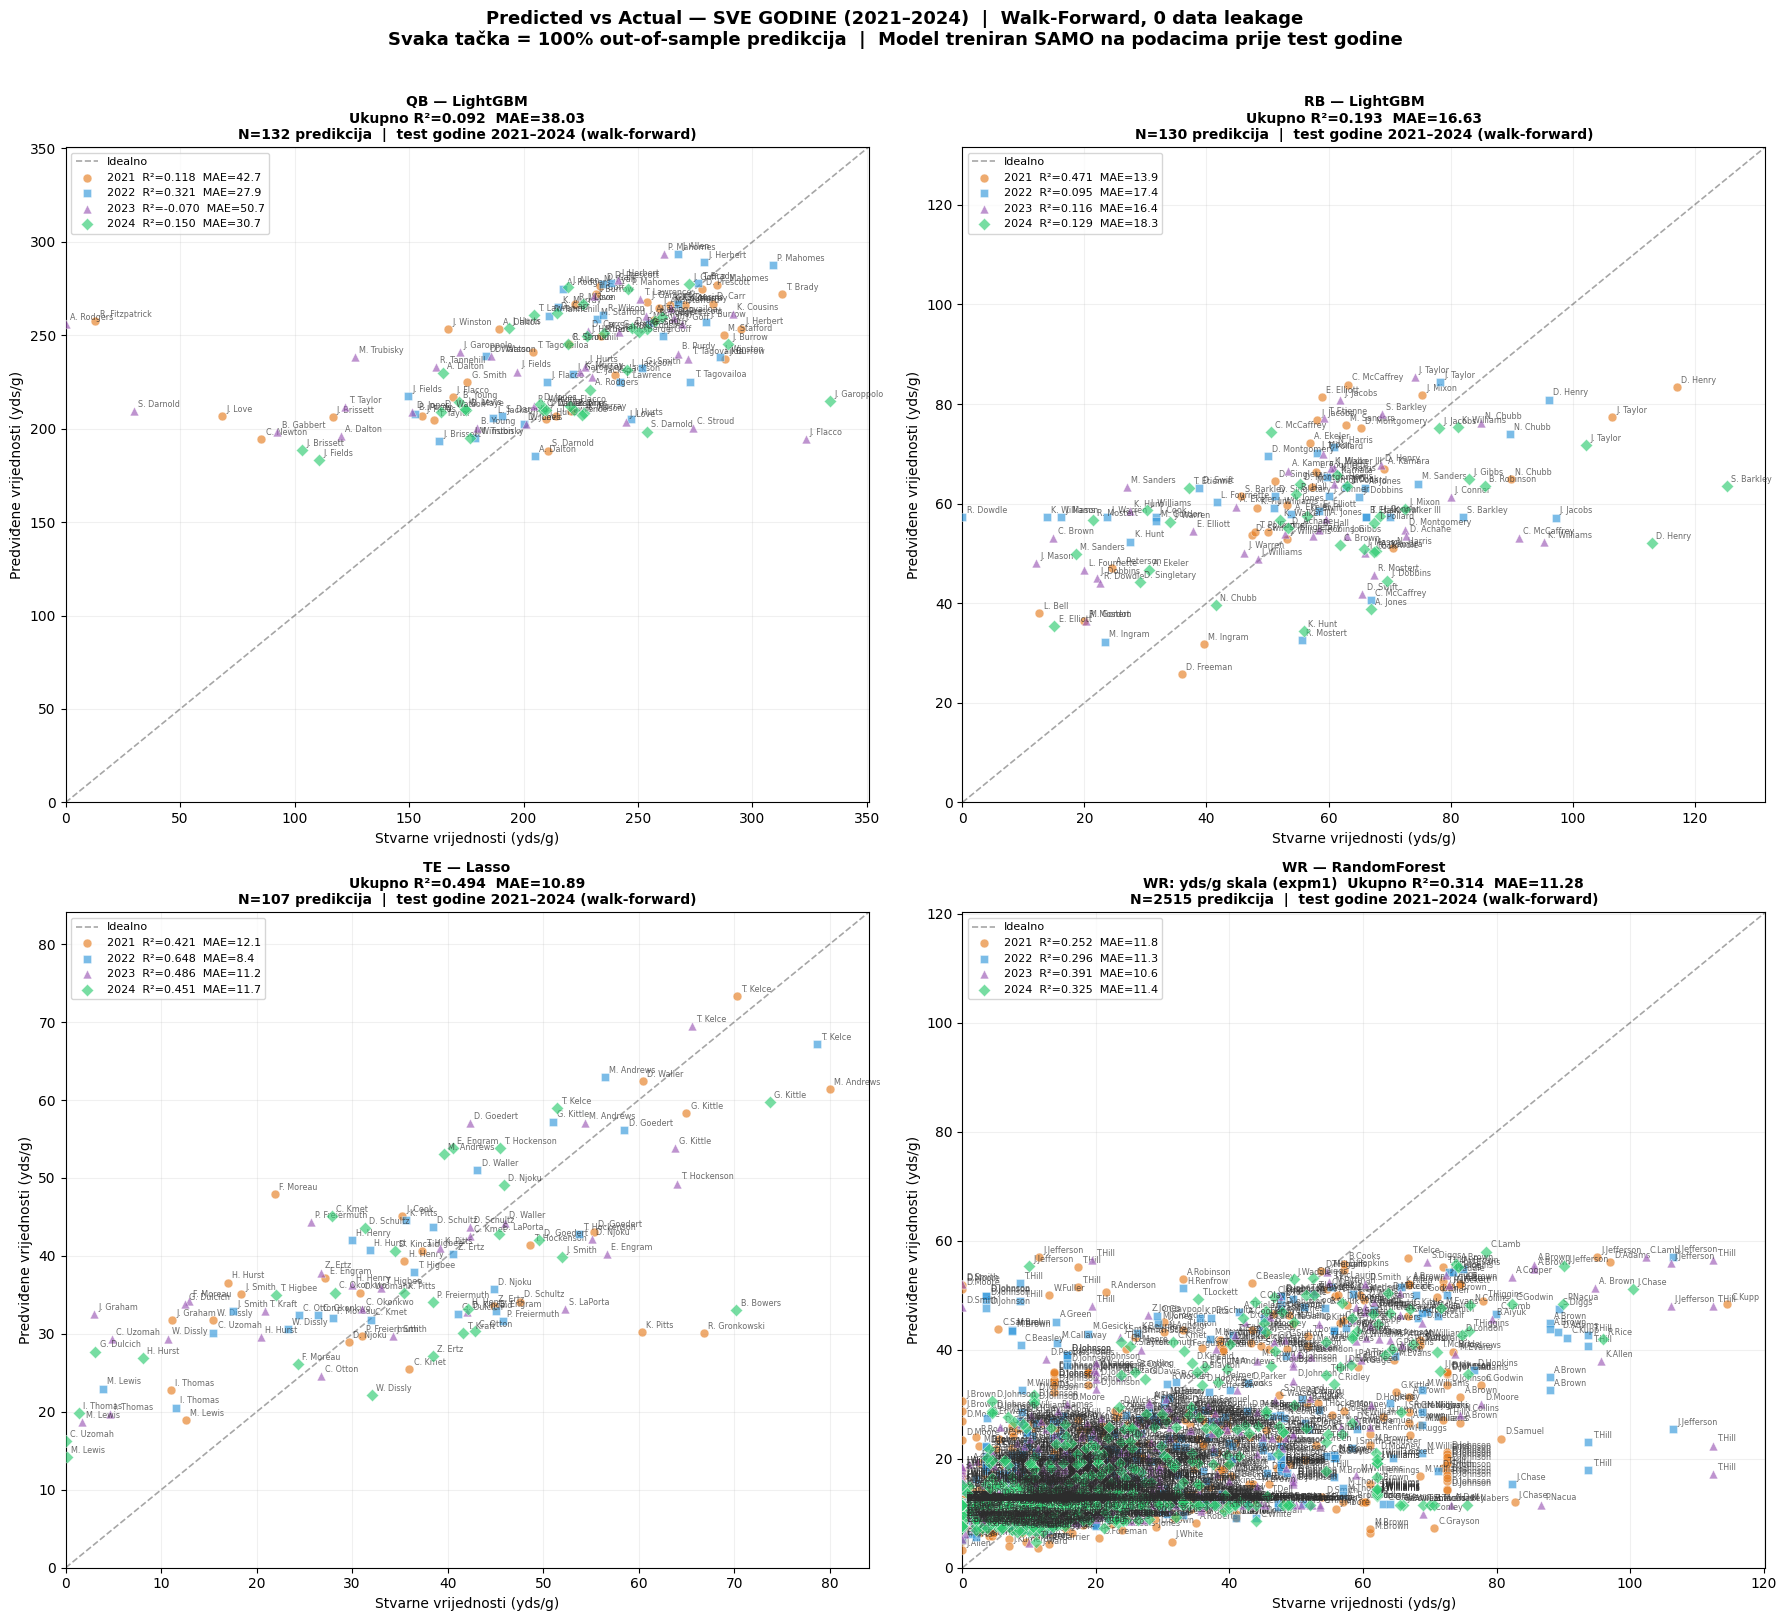


════════════════════════════════════════════════════════════════════
  Pregled metrika po poziciji i test godini (walk-forward)
════════════════════════════════════════════════════════════════════
  Pos    Godina     N       MAE      RMSE       R²
  ──────────────────────────────────────────────────────────
  QB       2021    33    42.700    64.201    0.118
  QB       2022    31    27.891    33.558    0.321
  QB       2023    33    50.684    74.875   -0.070
  QB       2024    35    30.693    41.459    0.150
  QB        AVG   132    38.034    56.145    0.092
  ──────────────────────────────────────────────────────────
  RB       2021    27    13.914    16.319    0.471
  RB       2022    33    17.380    22.136    0.095
  RB       2023    36    16.444    20.171    0.116
  RB       2024    34    18.270    23.275    0.129
  RB        AVG   130    16.634    20.834    0.193
  ──────────────────────────────────────────────────────────
  TE       2021    25    12.109    15.149    0.421
  TE   

In [23]:

# ══════════════════════════════════════════════════════════════════════════════
# ── Predicted vs Actual — SVE GODINE (2021–2024, walk-forward, 0 leakage) ───
# ══════════════════════════════════════════════════════════════════════════════
#
# Za svaki fold (test godine 2021, 2022, 2023, 2024):
#   • Model se trenira ISKLJUČIVO na podacima ≤ train_end (svježi imputer/scaler)
#   • Hiperparametri se uzimaju iz cal_best_params (već izračunato, nema grida)
#   • Svaka tačka je potpuno out-of-sample predikcija
#
# WR: predikcije i stvarne vrijednosti se konvertuju expm1() → yds/g skala.

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

FOLDS_ALL = [
    {'name': 'Fold 1', 'train_end': 2020, 'test_year': 2021},
    {'name': 'Fold 2', 'train_end': 2021, 'test_year': 2022},
    {'name': 'Fold 3', 'train_end': 2022, 'test_year': 2023},
    {'name': 'Fold 4', 'train_end': 2023, 'test_year': 2024},
]

YEAR_COLORS = {2021: '#e67e22', 2022: '#3498db', 2023: '#9b59b6', 2024: '#2ecc71'}
YEAR_MARKERS = {2021: 'o', 2022: 's', 2023: '^', 2024: 'D'}

PLAYER_COL = {'QB': 'Player', 'RB': 'Player', 'TE': 'Player', 'WR': 'receiver_player_name'}
SEASON_COL_POS = {'QB': 'Season', 'RB': 'Season', 'TE': 'Season', 'WR': 'season'}

# ── Prikupljanje predikcija za sve foldove ────────────────────────────────
all_preds = {pos: [] for pos in POSITIONS_ORDER}   # lista dict-ova po poziciji

for pos in POSITIONS_ORDER:
    best_name, _   = best_models[pos]
    scol           = SEASON_COL_POS[pos]
    id_cols        = POS_ID_COLS[pos]
    pcol           = PLAYER_COL[pos]
    df_full        = lagged[pos]
    feat_cols      = [c for c in df_full.columns if c not in id_cols + ['target']]
    is_wr          = (pos == 'WR')

    print(f'{pos} — treniranje po foldu ({best_name}) ...')

    for fold in FOLDS_ALL:
        train_end = fold['train_end']
        test_year = fold['test_year']

        tr_df = df_full[df_full[scol] <= train_end]
        te_df = df_full[df_full[scol] == test_year]
        if len(te_df) == 0:
            continue

        X_tr = tr_df[feat_cols].copy()
        y_tr = tr_df['target'].copy()
        X_te = te_df[feat_cols].copy()
        y_te = te_df['target'].copy()

        # lag2 NaN → 0
        lag2_c = [c for c in X_tr.columns if c.endswith('_lag2')]
        X_tr[lag2_c] = X_tr[lag2_c].fillna(0)
        X_te[lag2_c] = X_te[lag2_c].fillna(0)

        # Imputacija + skaliranje
        imp = SimpleImputer(strategy='median')
        X_tr_i = pd.DataFrame(imp.fit_transform(X_tr), columns=X_tr.columns)
        X_te_i = pd.DataFrame(imp.transform(X_te),     columns=X_te.columns)

        bin_c = [c for c in BINARY_COLS if c in X_tr.columns]
        num_c = [c for c in X_tr.columns if c not in bin_c]
        sc    = StandardScaler()
        X_tr_i[num_c] = sc.fit_transform(X_tr_i[num_c])
        X_te_i[num_c] = sc.transform(X_te_i[num_c])

        # Model s best params iz cal_best_params
        best_p = cal_best_params.get((pos, best_name, fold['name']), {})
        base_model = copy.deepcopy(CAL_MODEL_CONFIGS[best_name]['model'])
        if best_p:
            base_model.set_params(**best_p)
        base_model.fit(X_tr_i, y_tr)
        preds = base_model.predict(X_te_i)

        # WR inverz
        if is_wr:
            y_actual = np.expm1(y_te.values)
            y_pred   = np.expm1(preds)
        else:
            y_actual = y_te.values
            y_pred   = preds

        names = te_df[pcol].values

        for name, ya, yp in zip(names, y_actual, y_pred):
            all_preds[pos].append({'year': test_year, 'player': name,
                                   'actual': ya, 'pred': yp})

    n = sum(len(v) for v in [all_preds[pos]])
    print(f'  → {n} predikcija prikupljeno ({len(FOLDS_ALL)} folda)')


# ── Scatter: 4 subplota, sve godine obojene drugačije ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

for ax, pos in zip(axes.flat, POSITIONS_ORDER):
    records  = all_preds[pos]
    df_p     = pd.DataFrame(records)
    best_name, _ = best_models[pos]
    is_wr    = (pos == 'WR')

    all_actual = df_p['actual'].values
    all_pred   = df_p['pred'].values
    lo = min(all_actual.min(), all_pred.min()) * 0.92
    hi = max(all_actual.max(), all_pred.max()) * 1.05

    # Ideal line
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.35, linewidth=1.2, label='Idealno')

    for yr, grp in df_p.groupby('year'):
        ax.scatter(
            grp['actual'], grp['pred'],
            color=YEAR_COLORS[yr], marker=YEAR_MARKERS[yr],
            s=40, alpha=0.65, edgecolor='white', linewidth=0.4,
            label=str(yr),
            zorder=3,
        )
        # Anotacije igrača
        for _, row in grp.iterrows():
            parts = str(row['player']).split()
            short = f'{parts[0][0]}. {" ".join(parts[1:])}' if len(parts) > 1 else row['player']
            ax.annotate(short, xy=(row['actual'], row['pred']),
                        xytext=(3, 3), textcoords='offset points',
                        fontsize=5.8, alpha=0.70, color='#2c2c2c')

    # R² i MAE po svim godinama zajedno
    overall_r2  = r2_score(all_actual, all_pred)
    overall_mae = mean_absolute_error(all_actual, all_pred)

    # R² po godini
    yr_stats = df_p.groupby('year').apply(
        lambda g: pd.Series({
            'r2':  r2_score(g['actual'], g['pred']),
            'mae': mean_absolute_error(g['actual'], g['pred']),
        })
    )

    # Legenda s R² po godini
    handles, labels = ax.get_legend_handles_labels()
    new_labels = []
    for lbl in labels:
        if lbl.isdigit() and int(lbl) in yr_stats.index:
            r = yr_stats.loc[int(lbl), 'r2']
            m = yr_stats.loc[int(lbl), 'mae']
            new_labels.append(f'{lbl}  R²={r:.3f}  MAE={m:.1f}')
        else:
            new_labels.append(lbl)

    ax.legend(handles, new_labels, fontsize=8, loc='upper left')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('Stvarne vrijednosti (yds/g)', fontsize=10)
    ax.set_ylabel('Predviđene vrijednosti (yds/g)', fontsize=10)
    ax.set_title(
        f'{pos} — {best_name}\n'
        f'{"WR: yds/g skala (expm1)  " if is_wr else ""}'
        f'Ukupno R²={overall_r2:.3f}  MAE={overall_mae:.2f}\n'
        f'N={len(df_p)} predikcija  |  test godine 2021–2024 (walk-forward)',
        fontsize=10, fontweight='bold'
    )
    ax.grid(True, alpha=0.18)

fig.suptitle(
    'Predicted vs Actual — SVE GODINE (2021–2024)  |  Walk-Forward, 0 data leakage\n'
    'Svaka tačka = 100% out-of-sample predikcija  |  Model treniran SAMO na podacima prije test godine',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


# ── Tabelarni pregled R² i MAE po poziciji i godini ─────────────────────
print('\n' + '═'*68)
print('  Pregled metrika po poziciji i test godini (walk-forward)')
print('═'*68)
print(f'  {"Pos":<5} {"Godina":>7} {"N":>5} {"MAE":>9} {"RMSE":>9} {"R²":>8}')
print(f'  {"─"*58}')
for pos in POSITIONS_ORDER:
    df_p = pd.DataFrame(all_preds[pos])
    for yr, grp in df_p.groupby('year'):
        n    = len(grp)
        mae  = mean_absolute_error(grp['actual'], grp['pred'])
        rmse = np.sqrt(np.mean((grp['actual'] - grp['pred'])**2))
        r2   = r2_score(grp['actual'], grp['pred'])
        print(f'  {pos:<5} {yr:>7} {n:>5} {mae:>9.3f} {rmse:>9.3f} {r2:>8.3f}')
    # Prosjek
    all_a = df_p['actual'].values
    all_p_v = df_p['pred'].values
    print(f'  {pos:<5} {"AVG":>7} {len(df_p):>5} '
          f'{mean_absolute_error(all_a, all_p_v):>9.3f} '
          f'{np.sqrt(np.mean((all_a - all_p_v)**2)):>9.3f} '
          f'{r2_score(all_a, all_p_v):>8.3f}')
    print(f'  {"─"*58}')
